# ML Prep + Benchmark Workflow

This notebook loads extracted series features and heuristic labels, prepares model-ready train/val/test splits, and runs benchmark modeling with diagnostics.

It now covers both data-prep validation and model evaluation, including class-imbalance checks, per-class errors, feature usefulness analysis, and ROC visualizations.

In [1]:
from src.find_bids.models.classify.core import ml_prep_pipeline
from src.find_bids.models.classify.engineer import prepare_features_for_modeling
from src.find_bids.models.classify.pipeline_helpers import normalize_localizer_unknown_suffixes
from src.find_bids.models.extract.dataset import Dataset
from src.find_bids.models.extract.series import SeriesFeatures, get_features_from_db
from src.find_bids.models.infer.core import DatasetsInference

from upath import UPath
import math
import re
import warnings
from collections.abc import Mapping
from pathlib import Path
from typing import Protocol

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning, UndefinedMetricWarning
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    top_k_accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
from rich.progress import track

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

PROJECT_DIR = Path.cwd()
PROJECT_PLOTS_DIR = PROJECT_DIR / "outputs" / "plots"
PROJECT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
DB_PATH = UPath("/Volumes/csi/Quarles_Lab/find_BIDS/features/features.db")
ROOT_DIR = UPath("/Volumes/csi/Quarles_Lab/")

DATASET_FEATURE_PATHS = {
    "proactive": ROOT_DIR / "find_BIDS/features/PROACTIVE/dataset.json",
    "qiac": ROOT_DIR / "find_BIDS/features/QIAC/dataset.json",
}


def load_dataset_from_json(path: UPath) -> Dataset:
    if not path.exists():
        raise FileNotFoundError(f"Dataset features not found at {path}")
    return Dataset.from_json(path)


datasets = {
    name: load_dataset_from_json(path)
    for name, path in DATASET_FEATURE_PATHS.items()
}

list(datasets)

['proactive', 'qiac']

## Datasets Used In This Notebook

This notebook combines two feature collections:
- `proactive`: a dataset-specific JSON manifest under the PROACTIVE feature export directory
- `qiac`: a dataset-specific JSON manifest under the QIAC feature export directory

Each dataset manifest is used here for subject-level bookkeeping so that every extracted series and every heuristic inference row can be assigned back to its source dataset.

That dataset label is important because the ML prep pipeline merges rows on canonical keys: `dataset`, `subject_id`, `session_id`, and `series_id`.

In [3]:
def build_subject_to_dataset_map(datasets: dict[str, Dataset]) -> dict[str, str]:
    mapping: dict[str, str] = {}
    for dataset_name, dataset in datasets.items():
        for subject_name in dataset.subjects:
            mapping[subject_name] = dataset_name
    return mapping


def add_dataset_column(df: pd.DataFrame, mapping: dict[str, str]) -> pd.DataFrame:
    result = df.copy()
    result["dataset"] = result["subject_id"].map(mapping).fillna("unknown")
    ordered_columns = ["dataset"] + [col for col in result.columns if col != "dataset"]
    return result.loc[:, ordered_columns]


subject_to_dataset = build_subject_to_dataset_map(datasets)
pd.Series(subject_to_dataset, name="dataset").head()

2379-7808    proactive
2296-1674    proactive
2311-2679    proactive
2263-9275    proactive
2373-8978    proactive
Name: dataset, dtype: str

In [4]:
def expand_series_feature_rows(raw_df: pd.DataFrame) -> pd.DataFrame:
    if "data" not in raw_df.columns:
        return raw_df.copy()

    flat_rows = []
    for _, row in raw_df.iterrows():
        features = SeriesFeatures.from_json_str(row["data"]).flatten()
        flat_rows.append(
            {
                "subject_id": row["subject_id"],
                "session_id": row["session_id"],
                "series_id": row["series_id"],
                **features,
            }
        )
    return pd.DataFrame(flat_rows)


raw_features_from_db = get_features_from_db(
    db_path=DB_PATH,
    save=False,
    load_existing=True,
    to_series_features=False,
 )

if not isinstance(raw_features_from_db, pd.DataFrame):
    raise ValueError("Expected raw_features_from_db to be a DataFrame")

series_features_df = expand_series_feature_rows(raw_features_from_db)
series_features_df = add_dataset_column(series_features_df, subject_to_dataset)
series_features_df[["dataset", "subject_id", "session_id", "series_id"]].head()

Loading existing features from /Volumes/csi/Quarles_Lab/find_BIDS/features/all_series_features_from_db.csv


,dataset,subject_id,session_id,series_id
0,qiac,1012-3929,1012-3929-3589-0650,1.3.12.2.1107.5.2.18.141126.300000250124100121...
1,qiac,1012-3929,1012-3929-3589-0650,1.3.12.2.1107.5.2.18.141126.300000250124100121...
2,qiac,1012-3929,1012-3929-3589-0650,1.3.12.2.1107.5.2.18.141126.300000250124100810...
3,qiac,1012-3929,1012-3929-3589-0650,1.3.12.2.1107.5.2.18.141126.300000250124100810...
4,qiac,1012-3929,1012-3929-3589-0650,1.3.12.2.1107.5.2.18.141126.300000250124100810...


In [5]:
datasets_inference = DatasetsInference.from_db(
    datasets=list(datasets.values()),
    db_path=DB_PATH,
)

heuristic_scores_raw_df = add_dataset_column(
    datasets_inference.to_dataframe(),
    subject_to_dataset,
)

localizer_unknown_before = int(
    (
        heuristic_scores_raw_df["inferred_datatype"].astype("string").str.lower().eq("localizer")
        & heuristic_scores_raw_df["inferred_suffix"].astype("string").str.lower().eq("unknown")
    ).sum()
)
heuristic_scores_df = normalize_localizer_unknown_suffixes(heuristic_scores_raw_df)
localizer_unknown_after = int(
    (
        heuristic_scores_df["inferred_datatype"].astype("string").str.lower().eq("localizer")
        & heuristic_scores_df["inferred_suffix"].astype("string").str.lower().eq("unknown")
    ).sum()
)
normalized_localizer_count = localizer_unknown_before - localizer_unknown_after

heuristic_label_audit = pd.DataFrame(
    [
        {
            "metric": "localizer_unknown_before",
            "value": localizer_unknown_before,
        },
        {
            "metric": "localizer_unknown_after",
            "value": localizer_unknown_after,
        },
        {
            "metric": "normalized_localizer_rows",
            "value": normalized_localizer_count,
        },
    ]
)

display(heuristic_label_audit)
heuristic_scores_df[[
    "dataset",
    "subject_id",
    "session_id",
    "series_id",
    "inferred_datatype",
    "inferred_suffix",
    "min_confidence",
]].head()

Loading existing features from /Volumes/csi/Quarles_Lab/find_BIDS/features/all_series_features_from_db.csv


,metric,value
0,localizer_unknown_before,8787
1,localizer_unknown_after,0
2,normalized_localizer_rows,8787


,dataset,subject_id,session_id,series_id,inferred_datatype,inferred_suffix,min_confidence
0,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112911590867089...,localizer,localizer,0.582783
1,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912032862322...,anat,T2w,0.823201
2,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912070827969...,anat,FLAIR,0.525680
3,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912121751467...,anat,T2w,0.525680
4,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912150182192...,anat,T2starw,0.717083


## Generate Prepared Splits

This section builds model-ready splits from the raw feature table and heuristic labels.

We create both an unweighted version and a min-confidence-weighted version so the resulting `X`, `y`, and optional sample weights can be inspected before any model training.

## What Kinds Of Columns Do We Have?

The flattened `series_features_df` table contains several column families before ML-specific preprocessing:
- Identifier columns: `dataset`, `subject_id`, `session_id`, `series_id`, `study_uid`, `series_uid`
- Numeric columns: scanner geometry, timing, diffusion counts, repetition/echo measurements, and other continuous summaries
- Boolean columns: flags such as `is_original`, `is_adc`, `is_phase`, `has_diffusion`, and similar image-type indicators
- Categorical columns: manufacturer, model, scan option fields, acquisition type, phase-encoding metadata, and related low-cardinality descriptors
- Text columns: `series_description`, `protocol_name`, and `sequence_name`
- Raw structured columns: list- or tuple-like fields such as voxel size, b-values, echo times, and image orientation

During preprocessing, the pipeline converts these into a more model-friendly table by:
- parsing structured numeric fields into scalar summaries
- deriving acquisition and geometry features
- normalizing booleans and categorical values
- adding TF-IDF text features from the text columns
- dropping leakage-prone identifiers and raw metadata that should not appear in `X`

In [6]:
unweighted_sets = ml_prep_pipeline(
    series_features_df=series_features_df,
    heuristic_scores_df=heuristic_scores_df,
    sample_weighting_mode="none",
    tfidf_min_df=1,
    tfidf_max_features=120,
    tfidf_sequence_max_features=60,
    drop_unknown_in_train_val=True,
    min_confidence_weight_floor=0.3,
    random_state=42,
    train_fraction=0.7,
    val_fraction=0.15,
    test_fraction=0.15,
)

weighted_sets = ml_prep_pipeline(
    series_features_df=series_features_df,
    heuristic_scores_df=heuristic_scores_df,
    sample_weighting_mode="min_confidence",
    tfidf_min_df=1,
    tfidf_max_features=120,
    tfidf_sequence_max_features=60,
    drop_unknown_in_train_val=True,
    min_confidence_weight_floor=0.3,
    random_state=42,
    train_fraction=0.7,
    val_fraction=0.15,
    test_fraction=0.15,
)

sorted(unweighted_sets)

['all', 'test', 'train', 'val']

## Evaluate The Prepared Sets

The summary below checks the size of each split, the shape of `X` and `y`, the number of target classes, and whether sample weights are present.

This is a good checkpoint before training any models.

In [7]:
class PreparedSplitLike(Protocol):
    @property
    def X(self) -> pd.DataFrame: ...

    @property
    def y(self) -> pd.DataFrame: ...

    @property
    def sample_weight(self) -> pd.Series | None: ...


def summarize_prepared_sets(name: str, prepared_sets: Mapping[str, PreparedSplitLike]) -> pd.DataFrame:
    rows = []
    for split_name, split in prepared_sets.items():
        sample_weight = split.sample_weight
        rows.append(
            {
                "pipeline": name,
                "split": split_name,
                "rows": len(split.X),
                "features": split.X.shape[1],
                "targets": split.y.shape[1],
                "datatype_classes": int(split.y["inferred_datatype"].nunique()),
                "suffix_classes": int(split.y["inferred_suffix"].nunique()),
                "has_sample_weight": sample_weight is not None,
                "sample_weight_min": None if sample_weight is None else float(sample_weight.min()),
                "sample_weight_max": None if sample_weight is None else float(sample_weight.max()),
            }
        )
    return pd.DataFrame(rows)


evaluation_summary = pd.concat(
    [
        summarize_prepared_sets("unweighted", unweighted_sets),
        summarize_prepared_sets("weighted_min_confidence", weighted_sets),
    ],
    ignore_index=True,
)

train_X = unweighted_sets["train"].X
train_y = unweighted_sets["train"].y
val_X = unweighted_sets["val"].X
val_y = unweighted_sets["val"].y
test_X = unweighted_sets["test"].X
test_y = unweighted_sets["test"].y

evaluation_summary

,pipeline,split,rows,features,targets,datatype_classes,suffix_classes,has_sample_weight,sample_weight_min,sample_weight_max
0,unweighted,train,45474,522,2,6,28,False,None,None
1,unweighted,all,77489,522,2,7,29,False,None,None
2,unweighted,val,9773,522,2,6,23,False,None,None
3,unweighted,test,11622,522,2,7,25,False,None,None
4,weighted_min_confidence,train,45474,522,2,6,28,True,0.3,0.996454
5,weighted_min_confidence,all,77489,522,2,7,29,True,0.3,0.996454
6,weighted_min_confidence,val,9773,522,2,6,23,True,0.3,0.981368
7,weighted_min_confidence,test,11622,522,2,7,25,True,0.3,0.964028


In [8]:
pd.DataFrame({
    "feature": train_X.columns,
    "dtype": train_X.dtypes.astype(str).values,
}).head(50)

,feature,dtype
0,modality,str
1,series_number,float64
2,instances,object
3,num_instances,int64
4,num_unique_slices,int64
5,num_volumes,int64
6,field_strength,float64
7,rows,float64
8,columns,float64
9,num_slices,float64


In [9]:
debug_prepared = prepare_features_for_modeling(
    series_features_df,
    drop_raw_text=False,
    sparse_threshold=0.95,
    preserve_engineered_features=True,
)

pd.Series({
    "series_features_columns": len(series_features_df.columns),
    "prepared_columns": len(debug_prepared.columns),
    "prepared_numeric_columns": int(debug_prepared.select_dtypes(include=["number", "bool"]).shape[1]),
}).to_frame("value")

,value
series_features_columns,87
prepared_columns,357
prepared_numeric_columns,342


## Inspect Engineered Feature Families

Before looking at the final `train_X` / `val_X` / `test_X` tables, it helps to inspect the intermediate engineered table.

This intermediate view answers two questions:
- Are the raw series features being expanded correctly from the database payload?
- Are the expected engineered numeric, categorical, and text-derived columns surviving preprocessing before the final split-specific schema alignment step?

In [10]:
interesting_columns = [
    col
    for col in [
        "data",
        "series_description",
        "protocol_name",
        "sequence_name",
        "text_char_count",
        "text_token_count",
        "voxel_volume",
        "matrix_area",
        "acquisition_hour",
        "acquisition_order_rank",
        "source_image_sequences_present",
    ]
    if col in debug_prepared.columns
 ]

debug_prepared[interesting_columns].head() if interesting_columns else debug_prepared.head()

,series_description,protocol_name,sequence_name,text_char_count,text_token_count,voxel_volume,matrix_area,acquisition_hour,acquisition_order_rank,source_image_sequences_present
0,3Pl Loc_11M,3Pl Loc_11M,*fl3d1_ns,32.0,8.0,4.225000,25600.0,12.0,6.0,0.0
1,Ax DTI_TENSOR_B0,Ax DTI,*ep_b0_1000,34.0,9.0,16.143889,16384.0,12.0,6.0,0.0
2,Ax T2,Ax T2,*tse2d1_16,21.0,6.0,1.317862,169344.0,12.0,6.0,0.0
3,Ax T2star,Ax T2star,*fl2d1r,26.0,5.0,1.008989,221184.0,12.0,6.0,0.0
4,Ax T1,Ax T1,*se2d1,17.0,5.0,4.035954,59392.0,12.0,6.0,0.0


In [11]:
pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": len(split.X),
            "features": split.X.shape[1],
            "has_raw_data_column": "data" in split.X.columns,
            "sample_weight": split.sample_weight is not None,
        }
        for split_name, split in weighted_sets.items()
    ]
)

,split,rows,features,has_raw_data_column,sample_weight
0,train,45474,522,False,True
1,all,77489,522,False,True
2,val,9773,522,False,True
3,test,11622,522,False,True


## Why Some Columns Are Excluded From X

The training feature matrix `X` intentionally excludes columns that can cause leakage or unstable generalization.

Main exclusion groups:
- Raw payload columns (for example `data`) that are not direct model features
- Identifiers (`study_uid`, `series_uid`, and other UID-like fields) that encode row identity
- Label and confidence columns (`inferred_*`, `*_confidence`, `label*`) that would leak target information
- Raw text source columns after text vectorization when TF-IDF features are enabled

This separation is what allows us to safely train on engineered predictors while keeping outcome metadata only in `y` or in analysis tables.

## Feature Families In Final X

By this stage, final `X` columns are typically a mix of:
- Engineered numeric features (timing, geometry, diffusion/perfusion summaries, acquisition features)
- Binary keyword indicators (`kw_*`)
- One-hot categorical indicators (for low-cardinality scanner/acquisition fields)
- TF-IDF text features (`tfidf_*`) derived from description/protocol/sequence text

The next cells summarize how many columns belong to each family and then train several baseline models on both targets (`inferred_datatype` and `inferred_suffix`).

In [12]:
feature_family_summary = pd.DataFrame(
    [
        {
            "family": "tfidf",
            "count": int(train_X.columns.str.startswith("tfidf_").sum()),
        },
        {
            "family": "keyword_flags",
            "count": int(train_X.columns.str.startswith("kw_").sum()),
        },
        {
            "family": "missing_indicators",
            "count": int(train_X.columns.str.endswith("_missing").sum()),
        },
        {
            "family": "other_engineered_or_onehot",
            "count": int(
                len(train_X.columns)
                - train_X.columns.str.startswith("tfidf_").sum()
                - train_X.columns.str.startswith("kw_").sum()
                - train_X.columns.str.endswith("_missing").sum()
            ),
        },
    ]
)

feature_family_summary

,family,count
0,tfidf,180
1,keyword_flags,0
2,missing_indicators,60
3,other_engineered_or_onehot,282


## Baseline + Tuned ML Benchmark

This benchmark section now does four things:
- Compares multiple model families across both targets (`inferred_datatype`, `inferred_suffix`)
- Tries several hyperparameter variants per family (light tuning sweep)
- Uses optional confidence-weighted training (`sample_weight`)
- Reports richer metrics beyond accuracy, including macro ROC-AUC, log loss, and top-k accuracy

To keep runtime practical, training can be row-capped using `BENCHMARK_TRAIN_MAX_ROWS`. Set it to `None` to use all rows.

In [13]:
TARGETS = ["inferred_datatype", "inferred_suffix", "inferred_joint_label"]
BENCHMARK_RANDOM_STATE = 42
BENCHMARK_TRAIN_MAX_ROWS = 20000  # set to None for full training rows

MODEL_CANDIDATES = [
    ("dummy_most_frequent", DummyClassifier(strategy="most_frequent")),
    ("logreg_c1", LogisticRegression(C=1.0, max_iter=1200, solver="saga")),
    ("logreg_c3_balanced", LogisticRegression(C=3.0, max_iter=1200, solver="saga", class_weight="balanced")),
    (
        "rf_depth20",
        RandomForestClassifier(
            n_estimators=350, max_depth=20, min_samples_leaf=1, random_state=BENCHMARK_RANDOM_STATE, n_jobs=-1
        ),
    ),
    (
        "rf_depth20_balanced",
        RandomForestClassifier(
            n_estimators=350,
            max_depth=20,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            random_state=BENCHMARK_RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
    (
        "rf_depth30_leaf2",
        RandomForestClassifier(
            n_estimators=450, max_depth=30, min_samples_leaf=2, random_state=BENCHMARK_RANDOM_STATE, n_jobs=-1
        ),
    ),
    (
        "extra_trees_depth25",
        ExtraTreesClassifier(n_estimators=350, max_depth=25, random_state=BENCHMARK_RANDOM_STATE, n_jobs=-1),
    ),
    (
        "extra_trees_depth25_balanced",
        ExtraTreesClassifier(
            n_estimators=350,
            max_depth=25,
            class_weight="balanced_subsample",
            random_state=BENCHMARK_RANDOM_STATE,
            n_jobs=-1,
        ),
    ),
    (
        "extra_trees_depth35_leaf2",
        ExtraTreesClassifier(
            n_estimators=500, max_depth=35, min_samples_leaf=2, random_state=BENCHMARK_RANDOM_STATE, n_jobs=-1
        ),
    ),
    (
        "xgboost_depth6",
        XGBClassifier(
            objective="multi:softprob",
            n_estimators=350,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=BENCHMARK_RANDOM_STATE,
            n_jobs=-1,
            eval_metric="mlogloss",
            tree_method="hist",
        ),
    ),
    (
        "xgboost_depth8",
        XGBClassifier(
            objective="multi:softprob",
            n_estimators=450,
            max_depth=8,
            learning_rate=0.06,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=BENCHMARK_RANDOM_STATE,
            n_jobs=-1,
            eval_metric="mlogloss",
            tree_method="hist",
        ),
    ),
]


def _target_series_from_y(y_df: pd.DataFrame, target: str) -> pd.Series:
    if target == "inferred_joint_label":
        dtype_part = y_df["inferred_datatype"].astype("string").fillna("unknown")
        suffix_part = y_df["inferred_suffix"].astype("string").fillna("unknown")
        return (dtype_part + "::" + suffix_part).astype("string")
    return y_df[target].astype("string")


def _to_numeric_ml_matrix(X: pd.DataFrame) -> pd.DataFrame:
    matrix = X.copy()
    bool_cols = matrix.select_dtypes(include=["bool"]).columns
    if len(bool_cols) > 0:
        matrix[bool_cols] = matrix[bool_cols].astype("int8")
    return matrix.select_dtypes(include=["number"]).astype("float32")


def _maybe_cap_training_rows(
    X: pd.DataFrame, y: pd.Series, weights: pd.Series | None, max_rows: int | None = BENCHMARK_TRAIN_MAX_ROWS
) -> tuple[pd.DataFrame, pd.Series, pd.Series | None]:
    if max_rows is None or len(X) <= max_rows:
        return X, y, weights
    stratify_labels = y if y.value_counts(dropna=False).min() >= 2 else None
    X_sub, _, y_sub, _ = train_test_split(
        X, y, train_size=max_rows, random_state=BENCHMARK_RANDOM_STATE, stratify=stratify_labels
    )
    if weights is None:
        return X_sub, y_sub, None
    return X_sub, y_sub, weights.reindex(X_sub.index).fillna(weights.median() if len(weights) else 1.0)


def _safe_multiclass_auc(y_true: pd.Series, y_proba: pd.DataFrame, class_labels: list[str]) -> float | None:
    if len(class_labels) < 2:
        return None
    y_true_bin = label_binarize(y_true, classes=class_labels)
    if y_true_bin.shape[1] < 2:
        return None
    # Drop OVR columns that are all-zeros or all-ones (degenerate; avoids UndefinedMetricWarning)
    valid_cols = [i for i in range(y_true_bin.shape[1]) if 0 < y_true_bin[:, i].sum() < len(y_true_bin)]
    if len(valid_cols) < 2:
        return None
    try:
        return float(
            roc_auc_score(
                y_true_bin[:, valid_cols],
                y_proba.reindex(columns=class_labels, fill_value=0.0).to_numpy()[:, valid_cols],
                average="macro",
            )
        )
    except Exception:
        return None


def _safe_top_k_accuracy(y_true: pd.Series, y_proba: pd.DataFrame, class_labels: list[str], k: int) -> float | None:
    if len(class_labels) <= 1:
        return None
    try:
        return float(
            top_k_accuracy_score(
                y_true,
                y_proba.reindex(columns=class_labels, fill_value=0.0).to_numpy(),
                labels=class_labels,
                k=min(k, len(class_labels)),
            )
        )
    except Exception:
        return None


def _evaluate_predictions(
    y_true: pd.Series, y_pred: pd.Series, y_proba: pd.DataFrame | None, class_labels: list[str]
) -> dict[str, float | None]:
    eval_mask = y_true.notna() & y_pred.notna() & y_true.isin(class_labels) & y_pred.isin(class_labels)
    y_true_eval = y_true[eval_mask].astype("string")
    y_pred_eval = y_pred[eval_mask].astype("string")
    # Restrict metric labels to classes actually present in y_true_eval.
    # This prevents f1_score from averaging in zero-F1 for classes the model predicts
    # but that happen not to appear in this eval partition (which deflates macro-F1).
    eval_labels = sorted(y_true_eval.unique().tolist())

    f1_macro_value: float | None = None
    if len(y_true_eval):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UserWarning)
            f1_macro_value = float(
                f1_score(y_true_eval, y_pred_eval, average="macro", zero_division=0, labels=eval_labels)
            )

    metrics: dict[str, float | None] = {
        "accuracy": float(accuracy_score(y_true_eval, y_pred_eval)) if len(y_true_eval) else None,
        "balanced_accuracy": float(balanced_accuracy_score(y_true_eval, y_pred_eval)) if len(y_true_eval) else None,
        "f1_macro": f1_macro_value,
        "auc_macro_ovr": None,
        "log_loss": None,
        "top2_accuracy": None,
        "top3_accuracy": None,
    }
    if y_proba is None or len(y_true_eval) == 0:
        return metrics

    proba = y_proba.loc[y_true_eval.index].reindex(columns=class_labels, fill_value=0.0).clip(lower=1e-12, upper=1.0)
    proba = proba.div(proba.sum(axis=1), axis=0).fillna(1.0 / max(1, len(class_labels)))
    metrics["auc_macro_ovr"] = _safe_multiclass_auc(y_true_eval, proba, class_labels)
    try:
        metrics["log_loss"] = float(log_loss(y_true_eval, proba, labels=class_labels))
    except Exception:
        metrics["log_loss"] = None
    metrics["top2_accuracy"] = _safe_top_k_accuracy(y_true_eval, proba, class_labels, k=2)
    metrics["top3_accuracy"] = _safe_top_k_accuracy(y_true_eval, proba, class_labels, k=3)
    return metrics


def _sanitize_xgb_columns(X: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, str]]:
    col_map: dict[str, str] = {}
    used: set[str] = set()
    for col in X.columns:
        safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(col)).strip("_")
        safe = safe or "col"
        candidate = safe
        suffix = 1
        while candidate in used:
            candidate = f"{safe}_{suffix}"
            suffix += 1
        used.add(candidate)
        col_map[col] = candidate
    return X.rename(columns=col_map), col_map


def _fit_model_once(
    model,
    model_name: str,
    X_train: pd.DataFrame,
    y_train_target: pd.Series,
    fit_kwargs: dict,
    class_labels: list[str],
):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        warnings.filterwarnings("ignore", category=UserWarning)
        warnings.filterwarnings("ignore", category=FutureWarning)

        if model_name.startswith("xgboost"):
            # Derive encoding from the actual training labels to guarantee a
            # contiguous 0..N-1 mapping even when y_train_target is a subsample
            # of a larger label universe (e.g. after BENCHMARK_TRAIN_MAX_ROWS cap).
            actual_classes = sorted(y_train_target.dropna().unique().tolist())
            label_to_int = {label: idx for idx, label in enumerate(actual_classes)}
            y_encoded = y_train_target.map(label_to_int).astype(int)
            X_train_safe, col_map = _sanitize_xgb_columns(X_train)
            model.fit(X_train_safe, y_encoded, **fit_kwargs)
            return {"is_xgb": True, "label_to_int": label_to_int, "col_map": col_map}

        model.fit(X_train, y_train_target, **fit_kwargs)
        return {"is_xgb": False, "label_to_int": None, "col_map": None}


def _predict_model(
    model,
    fit_info: dict,
    X_eval: pd.DataFrame,
    class_labels: list[str],
) -> tuple[pd.Series, pd.DataFrame | None]:
    if fit_info["is_xgb"]:
        int_to_label = {v: k for k, v in fit_info["label_to_int"].items()}
        col_map = fit_info["col_map"]
        X_eval_safe = X_eval.rename(columns=col_map)
        pred_int = pd.Series(model.predict(X_eval_safe), index=X_eval.index).astype(int)
        y_pred = pred_int.map(int_to_label).astype("string")
        # Use the classes the model was actually trained on for proba columns;
        # _evaluate_predictions reindexes to class_labels and fills missing with 0.
        fitted_classes = [k for k, v in sorted(fit_info["label_to_int"].items(), key=lambda x: x[1])]
        y_proba = pd.DataFrame(
            model.predict_proba(X_eval_safe),
            index=X_eval.index,
            columns=fitted_classes,
            dtype="float64",
        )
        return y_pred, y_proba

    y_pred = pd.Series(model.predict(X_eval), index=X_eval.index, dtype="string")
    if not hasattr(model, "predict_proba"):
        return y_pred, None
    proba_np = model.predict_proba(X_eval)
    if isinstance(proba_np, list):
        return y_pred, None
    model_classes = [str(c) for c in getattr(model, "classes_", class_labels)]
    y_proba = pd.DataFrame(proba_np, index=X_eval.index, columns=model_classes, dtype="float64")
    return y_pred, y_proba


def run_model_benchmark(
    prepared_sets: dict[str, object],
    benchmark_name: str,
    use_sample_weight: bool,
    targets: list[str] = TARGETS,
) -> pd.DataFrame:
    X_train_full = _to_numeric_ml_matrix(prepared_sets["train"].X)
    X_val = _to_numeric_ml_matrix(prepared_sets["val"].X).reindex(columns=X_train_full.columns, fill_value=0.0)
    X_test = _to_numeric_ml_matrix(prepared_sets["test"].X).reindex(columns=X_train_full.columns, fill_value=0.0)

    y_train = prepared_sets["train"].y
    y_val = prepared_sets["val"].y
    y_test = prepared_sets["test"].y

    weights_full = None
    if use_sample_weight and getattr(prepared_sets["train"], "sample_weight", None) is not None:
        weights_full = getattr(prepared_sets["train"], "sample_weight").reindex(X_train_full.index).fillna(1.0)

    rows = []
    for target in targets:
        y_train_target_full = _target_series_from_y(y_train, target)
        y_val_target = _target_series_from_y(y_val, target)
        y_test_target = _target_series_from_y(y_test, target)

        X_train, y_train_target, weights = _maybe_cap_training_rows(
            X_train_full, y_train_target_full, weights_full, max_rows=BENCHMARK_TRAIN_MAX_ROWS
        )
        # Derive class_labels from the (possibly capped) training data so the
        # integer encoding in _fit_model_once is always contiguous 0..N-1.
        class_labels = sorted(y_train_target.dropna().unique().tolist())

        for model_name, base_model in track(MODEL_CANDIDATES, description=f"Training models for target '{target}'..."):
            model = clone(base_model)
            fit_kwargs = {}
            if weights is not None and model_name != "dummy_most_frequent":
                fit_kwargs["sample_weight"] = weights

            fit_info = _fit_model_once(
                model=model,
                model_name=model_name,
                X_train=X_train,
                y_train_target=y_train_target,
                fit_kwargs=fit_kwargs,
                class_labels=class_labels,
            )

            val_pred, val_proba = _predict_model(model, fit_info, X_val, class_labels)
            test_pred, test_proba = _predict_model(model, fit_info, X_test, class_labels)

            val_metrics = _evaluate_predictions(y_val_target, val_pred, val_proba, class_labels)
            test_metrics = _evaluate_predictions(y_test_target, test_pred, test_proba, class_labels)

            rows.append(
                {
                    "benchmark": benchmark_name,
                    "target": target,
                    "model": model_name,
                    "train_rows": len(X_train),
                    "features": X_train.shape[1],
                    "weighted_training": bool(weights is not None and model_name != "dummy_most_frequent"),
                    "val_accuracy": val_metrics["accuracy"],
                    "val_balanced_accuracy": val_metrics["balanced_accuracy"],
                    "val_f1_macro": val_metrics["f1_macro"],
                    "val_auc_macro_ovr": val_metrics["auc_macro_ovr"],
                    "val_log_loss": val_metrics["log_loss"],
                    "val_top2_accuracy": val_metrics["top2_accuracy"],
                    "val_top3_accuracy": val_metrics["top3_accuracy"],
                    "test_accuracy": test_metrics["accuracy"],
                    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                    "test_f1_macro": test_metrics["f1_macro"],
                    "test_auc_macro_ovr": test_metrics["auc_macro_ovr"],
                    "test_log_loss": test_metrics["log_loss"],
                    "test_top2_accuracy": test_metrics["top2_accuracy"],
                    "test_top3_accuracy": test_metrics["top3_accuracy"],
                }
            )

    return pd.DataFrame(rows)

In [14]:
benchmark_unweighted = run_model_benchmark(
    prepared_sets=unweighted_sets,
    benchmark_name="unweighted",
    use_sample_weight=False,
)

benchmark_weighted = run_model_benchmark(
    prepared_sets=weighted_sets,
    benchmark_name="weighted_min_confidence",
    use_sample_weight=True,
)

model_results = pd.concat([benchmark_unweighted, benchmark_weighted], ignore_index=True)

analysis_columns = [
    "benchmark",
    "target",
    "model",
    "weighted_training",
    "train_rows",
    "features",
    "val_f1_macro",
    "val_auc_macro_ovr",
    "val_log_loss",
    "test_f1_macro",
    "test_auc_macro_ovr",
    "test_log_loss",
    "test_balanced_accuracy",
    "test_top2_accuracy",
    "test_top3_accuracy",
]

model_results.sort_values(
    by=["target", "test_f1_macro", "test_auc_macro_ovr", "test_balanced_accuracy"],
    ascending=[True, False, False, False],
)[analysis_columns].head(30)

Output()

Output()

/Users/cmokashi/Documents/GitHub/find_BIDS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:29
24: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")

/Users/cmokashi/Documents/GitHub/find_BIDS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:29
24: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")

Output()

...

/Users/cmokashi/Documents/GitHub/find_BIDS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:29
24: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")

Output()

/Users/cmokashi/Documents/GitHub/find_BIDS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:29
24: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")

/Users/cmokashi/Documents/GitHub/find_BIDS/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:29
24: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")

,benchmark,target,model,weighted_training,train_rows,features,val_f1_macro,val_auc_macro_ovr,val_log_loss,test_f1_macro,test_auc_macro_ovr,test_log_loss,test_balanced_accuracy,test_top2_accuracy,test_top3_accuracy
5,unweighted,inferred_datatype,rf_depth30_leaf2,False,20000,519,0.954567,0.999782,0.018197,0.917184,0.999597,0.020415,0.940864,0.999017,0.999464
38,weighted_min_confidence,inferred_datatype,rf_depth30_leaf2,True,20000,519,0.958008,0.999791,0.018297,0.914922,0.999537,0.020567,0.938168,0.998928,0.999732
9,unweighted,inferred_datatype,xgboost_depth6,False,20000,519,0.975969,0.999918,0.011678,0.908686,0.999815,0.011141,0.956168,0.999285,0.999821
42,weighted_min_confidence,inferred_datatype,xgboost_depth6,True,20000,519,0.975500,0.999923,0.010853,0.908654,0.999772,0.011054,0.956071,0.999464,0.999911
10,unweighted,inferred_datatype,xgboost_depth8,False,20000,519,0.975614,0.999910,0.012787,0.907375,0.999826,0.011192,0.955912,0.999375,0.999911
43,weighted_min_confidence,inferred_datatype,xgboost_depth8,True,20000,519,0.975829,0.999920,0.011104,0.905297,0.999766,0.010986,0.951134,0.999553,0.999911
37,weighted_min_confidence,inferred_datatype,rf_depth20_balanced,True,20000,519,0.957255,0.999832,0.015083,0.904223,0.999597,0.017891,0.961050,0.999107,0.999553
4,unweighted,inferred_datatype,rf_depth20_balanced,False,20000,519,0.957683,0.999831,0.014967,0.902388,0.999613,0.017699,0.963451,0.999107,0.999732
8,unweighted,inferred_datatype,extra_trees_depth35_leaf2,False,20000,519,0.957686,0.999847,0.017669,0.902069,0.999629,0.019566,0.945436,0.999196,0.999732
36,weighted_min_confidence,inferred_datatype,rf_depth20,True,20000,519,0.957780,0.999861,0.014992,0.900781,0.999631,0.018195,0.945322,0.998928,0.999732


,target,benchmark,model,weighted_training,train_rows,features,val_f1_macro,val_auc_macro_ovr,test_f1_macro,test_auc_macro_ovr,test_balanced_accuracy,test_top2_accuracy,test_top3_accuracy
0,inferred_datatype,unweighted,rf_depth30_leaf2,False,20000,519,0.954567,0.999782,0.917184,0.999597,0.940864,0.999017,0.999464
1,inferred_datatype,weighted_min_confidence,rf_depth30_leaf2,True,20000,519,0.958008,0.999791,0.914922,0.999537,0.938168,0.998928,0.999732
2,inferred_joint_label,unweighted,extra_trees_depth35_leaf2,False,20000,519,0.837352,0.999818,0.834270,0.999799,0.803724,0.997427,0.998868
3,inferred_joint_label,weighted_min_confidence,extra_trees_depth25,True,20000,519,0.850464,0.999728,0.826527,0.999797,0.818212,0.997941,0.998765
4,inferred_suffix,unweighted,xgboost_depth8,False,20000,519,0.828246,0.999758,0.854616,0.999559,0.832683,0.998353,0.999177
5,inferred_suffix,weighted_min_confidence,extra_trees_depth25_balanced,True,20000,519,0.881893,0.999662,0.826426,0.999757,0.821875,0.997633,0.998765


,target,benchmark,model,val_f1_macro,test_f1_macro,f1_gap_val_minus_test,val_auc_macro_ovr,test_auc_macro_ovr,auc_gap_val_minus_test,test_balanced_accuracy,overfit_flag,low_perf_flag
0,inferred_datatype,unweighted,rf_depth30_leaf2,0.954567,0.917184,0.037383,0.999782,0.999597,0.000185,0.940864,False,False
1,inferred_datatype,weighted_min_confidence,rf_depth30_leaf2,0.958008,0.914922,0.043085,0.999791,0.999537,0.000255,0.938168,False,False
2,inferred_joint_label,unweighted,extra_trees_depth35_leaf2,0.837352,0.834270,0.003082,0.999818,0.999799,0.000020,0.803724,False,False
3,inferred_joint_label,weighted_min_confidence,extra_trees_depth25,0.850464,0.826527,0.023936,0.999728,0.999797,-0.000069,0.818212,False,False
4,inferred_suffix,unweighted,xgboost_depth8,0.828246,0.854616,-0.026370,0.999758,0.999559,0.000199,0.832683,False,False
5,inferred_suffix,weighted_min_confidence,extra_trees_depth25_balanced,0.881893,0.826426,0.055467,0.999662,0.999757,-0.000095,0.821875,True,False


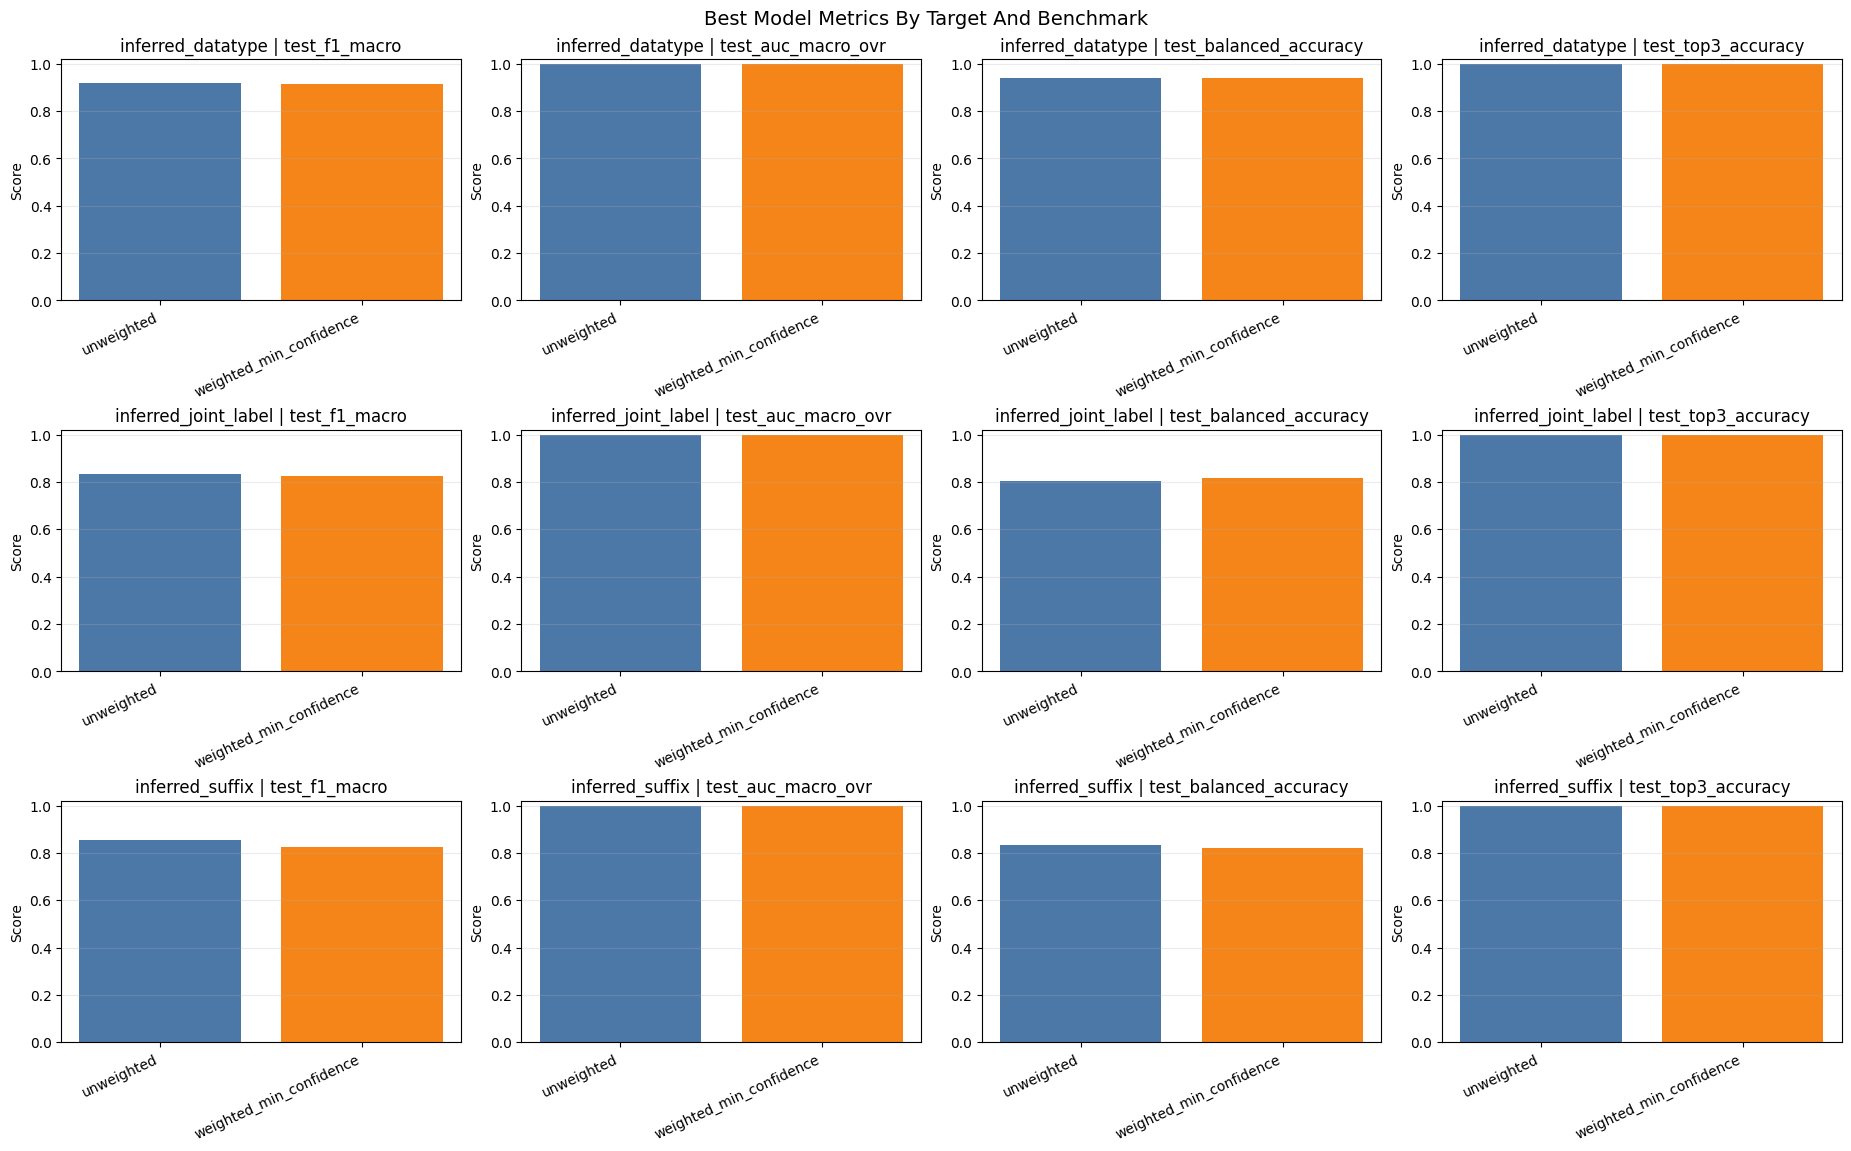

Saved benchmark metric grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/benchmark/best_model_metrics_grid.png


In [15]:
best_by_target = (
    model_results.sort_values(
        by=["target", "test_f1_macro", "test_auc_macro_ovr", "test_balanced_accuracy"],
        ascending=[True, False, False, False],
    )
    .groupby(["target", "benchmark"], as_index=False)
    .first()
    .sort_values(["target", "test_f1_macro"], ascending=[True, False])
)

summary_cols = [
    "target",
    "benchmark",
    "model",
    "weighted_training",
    "train_rows",
    "features",
    "val_f1_macro",
    "val_auc_macro_ovr",
    "test_f1_macro",
    "test_auc_macro_ovr",
    "test_balanced_accuracy",
    "test_top2_accuracy",
    "test_top3_accuracy",
]
display(best_by_target[summary_cols])

diagnostics = model_results.copy()
diagnostics["f1_gap_val_minus_test"] = diagnostics["val_f1_macro"] - diagnostics["test_f1_macro"]
diagnostics["auc_gap_val_minus_test"] = diagnostics["val_auc_macro_ovr"] - diagnostics["test_auc_macro_ovr"]

best_diagnostics = (
    diagnostics.sort_values(
        by=["target", "test_f1_macro", "test_auc_macro_ovr", "test_balanced_accuracy"],
        ascending=[True, False, False, False],
    )
    .groupby(["target", "benchmark"], as_index=False)
    .first()
)

best_diagnostics["overfit_flag"] = (
    (best_diagnostics["f1_gap_val_minus_test"] > 0.05)
    | (best_diagnostics["auc_gap_val_minus_test"] > 0.05)
)
best_diagnostics["low_perf_flag"] = (
    (best_diagnostics["test_f1_macro"] < 0.80)
    | (best_diagnostics["test_balanced_accuracy"] < 0.80)
)

display(
    best_diagnostics[[
        "target",
        "benchmark",
        "model",
        "val_f1_macro",
        "test_f1_macro",
        "f1_gap_val_minus_test",
        "val_auc_macro_ovr",
        "test_auc_macro_ovr",
        "auc_gap_val_minus_test",
        "test_balanced_accuracy",
        "overfit_flag",
        "low_perf_flag",
    ]]
)

plot_dir = PROJECT_PLOTS_DIR / "benchmark"
plot_dir.mkdir(parents=True, exist_ok=True)

metrics_to_plot = [
    "test_f1_macro",
    "test_auc_macro_ovr",
    "test_balanced_accuracy",
    "test_top3_accuracy",
]

targets = best_diagnostics["target"].dropna().unique().tolist()
fig, axes = plt.subplots(
    nrows=len(targets),
    ncols=len(metrics_to_plot),
    figsize=(4.6 * len(metrics_to_plot), 3.8 * max(1, len(targets))),
    squeeze=False,
    constrained_layout=True,
)

for r, target in enumerate(targets):
    target_rows = best_diagnostics[best_diagnostics["target"] == target].copy()
    target_rows = target_rows.sort_values("benchmark")
    x = range(len(target_rows))
    x_labels = target_rows["benchmark"].tolist()

    for c, metric in enumerate(metrics_to_plot):
        ax = axes[r][c]
        ax.bar(x, target_rows[metric].fillna(0.0), color=["#4C78A8", "#F58518"])
        ax.set_xticks(list(x))
        ax.set_xticklabels(x_labels, rotation=25, ha="right")
        ax.set_ylim(0.0, 1.02)
        ax.set_title(f"{target} | {metric}")
        ax.set_ylabel("Score")
        ax.grid(axis="y", alpha=0.25)

fig.suptitle("Best Model Metrics By Target And Benchmark", fontsize=14)
metrics_grid_path = plot_dir / "best_model_metrics_grid.png"
fig.savefig(metrics_grid_path, dpi=170, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved benchmark metric grid: {metrics_grid_path}")

### What This Grid Shows

For each target, this grid compares the best unweighted and weighted configurations on key test metrics.

Quick read:
- Higher `test_f1_macro` and `test_balanced_accuracy` indicate better class-level generalization, especially for minority classes.
- `test_auc_macro_ovr` near 1.0 suggests good class ranking, but does not guarantee high hard-label F1.
- If weighting helps, the weighted bars should move up for F1 and balanced accuracy.

In [16]:
MODEL_LOOKUP = {name: model for name, model in MODEL_CANDIDATES}
ROC_PLOT_DIR = PROJECT_PLOTS_DIR / "roc"
ROC_PLOT_DIR.mkdir(parents=True, exist_ok=True)
PR_PLOT_DIR = PROJECT_PLOTS_DIR / "precision_recall"
PR_PLOT_DIR.mkdir(parents=True, exist_ok=True)


def _safe_plot_slug(value: str) -> str:
    slug = re.sub(r"[^0-9a-zA-Z_\-]+", "_", str(value)).strip("_").lower()
    return slug or "plot"


def fit_model_for_target(
    prepared_sets: dict[str, object],
    target: str,
    model_name: str,
    use_sample_weight: bool,
) -> tuple[object, dict, pd.DataFrame, pd.Series, list[str]]:
    X_train = _to_numeric_ml_matrix(prepared_sets["train"].X)
    X_test = _to_numeric_ml_matrix(prepared_sets["test"].X).reindex(columns=X_train.columns, fill_value=0.0)
    y_train = _target_series_from_y(prepared_sets["train"].y, target)
    y_test = _target_series_from_y(prepared_sets["test"].y, target)

    sample_weights = prepared_sets["train"].sample_weight if use_sample_weight else None
    X_train, y_train, sample_weights = _maybe_cap_training_rows(
        X_train,
        y_train,
        sample_weights,
        max_rows=BENCHMARK_TRAIN_MAX_ROWS,
    )

    class_labels = sorted(y_train.dropna().unique().tolist())
    model = clone(MODEL_LOOKUP[model_name])
    fit_kwargs = {}
    if sample_weights is not None and model_name != "dummy_most_frequent":
        fit_kwargs["sample_weight"] = sample_weights.reindex(X_train.index).fillna(1.0)

    fit_info = _fit_model_once(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train_target=y_train,
        fit_kwargs=fit_kwargs,
        class_labels=class_labels,
    )
    return model, fit_info, X_test, y_test, class_labels


def plot_multiclass_roc_for_best_models(
    results_df: pd.DataFrame,
    prepared_sets_map: dict[str, dict[str, object]],
    top_classes_to_plot: int = 6,
) -> list[Path]:
    best_rows = (
        results_df.sort_values(
            by=["target", "test_f1_macro", "test_auc_macro_ovr"],
            ascending=[True, False, False],
        )
        .groupby("target", as_index=False)
        .first()
    )

    display(best_rows[["target", "benchmark", "model", "test_f1_macro", "test_auc_macro_ovr"]])

    saved_paths: list[Path] = []

    for _, row in best_rows.iterrows():
        target = row["target"]
        benchmark = row["benchmark"]
        model_name = row["model"]
        prepared_sets = prepared_sets_map[benchmark]
        use_sample_weight = benchmark == "weighted_min_confidence"
        print(f"Evaluating ROC using model={model_name}, target={target}, benchmark={benchmark}")

        model, fit_info, X_test, y_test, class_labels = fit_model_for_target(
            prepared_sets=prepared_sets,
            target=target,
            model_name=model_name,
            use_sample_weight=use_sample_weight,
        )

        _, y_proba = _predict_model(
            model=model,
            fit_info=fit_info,
            X_eval=X_test,
            class_labels=class_labels,
        )

        if y_proba is None or len(class_labels) < 2:
            print(f"Skipping ROC for {target}: no probability outputs or too few classes.")
            continue

        y_eval = y_test.dropna().astype("string")
        y_eval = y_eval[y_eval.isin(class_labels)]
        y_proba = y_proba.loc[y_eval.index].reindex(columns=class_labels, fill_value=0.0)
        y_test_bin = label_binarize(y_eval, classes=class_labels)

        valid_class_names: list[str] = []
        for i, class_name in enumerate(class_labels):
            col = y_test_bin[:, i]
            if col.sum() > 0 and col.sum() < len(col):
                valid_class_names.append(class_name)

        if not valid_class_names:
            print(f"Skipping ROC for {target}: test split has no valid one-vs-rest class labels.")
            continue

        top_classes = y_eval.value_counts().head(top_classes_to_plot).index.astype("string").tolist()
        classes_to_plot = [c for c in top_classes if c in valid_class_names]
        if not classes_to_plot:
            classes_to_plot = valid_class_names[:top_classes_to_plot]

        total_panels = 1 + len(classes_to_plot)
        ncols = 3
        nrows = math.ceil(total_panels / ncols)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(5.0 * ncols, 3.8 * nrows),
            squeeze=False,
            constrained_layout=True,
        )
        flat_axes = [ax for row_axes in axes for ax in row_axes]

        valid_indices = [class_labels.index(c) for c in valid_class_names]
        y_bin_valid = y_test_bin[:, valid_indices]
        y_score_valid = y_proba.iloc[:, valid_indices].to_numpy()

        micro_fpr, micro_tpr, _ = roc_curve(y_bin_valid.ravel(), y_score_valid.ravel())
        micro_auc = auc(micro_fpr, micro_tpr)

        ax0 = flat_axes[0]
        ax0.plot(micro_fpr, micro_tpr, color="black", linewidth=2.4, label=f"micro-average AUC={micro_auc:.3f}")
        ax0.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.0)
        ax0.set_title("Micro-average ROC")
        ax0.set_xlabel("False Positive Rate")
        ax0.set_ylabel("True Positive Rate")
        ax0.grid(alpha=0.25)
        ax0.legend(loc="lower right")

        for plot_idx, class_name in enumerate(classes_to_plot, start=1):
            ax = flat_axes[plot_idx]
            class_idx = class_labels.index(class_name)
            y_true_cls = y_test_bin[:, class_idx]
            y_score_cls = y_proba.iloc[:, class_idx].to_numpy()

            fpr, tpr, _ = roc_curve(y_true_cls, y_score_cls)
            class_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color="#4C78A8", linewidth=2.0, label=f"AUC={class_auc:.3f}")
            ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.0)
            ax.set_title(f"Class: {class_name}")
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.grid(alpha=0.25)
            ax.legend(loc="lower right")

        for ax in flat_axes[total_panels:]:
            ax.axis("off")

        fig.suptitle(f"ROC Grid | target={target} | model={model_name} | benchmark={benchmark}", fontsize=14)

        out_name = f"roc_grid_{_safe_plot_slug(target)}_{_safe_plot_slug(model_name)}_{_safe_plot_slug(benchmark)}.png"
        out_path = ROC_PLOT_DIR / out_name
        fig.savefig(out_path, dpi=170, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        saved_paths.append(out_path)
        print(f"Saved ROC grid: {out_path}")

    return saved_paths


def plot_multiclass_pr_for_best_models(
    results_df: pd.DataFrame,
    prepared_sets_map: dict[str, dict[str, object]],
    top_classes_to_plot: int = 6,
) -> list[Path]:
    best_rows = (
        results_df.sort_values(
            by=["target", "test_f1_macro", "test_auc_macro_ovr"],
            ascending=[True, False, False],
        )
        .groupby("target", as_index=False)
        .first()
    )

    display(best_rows[["target", "benchmark", "model", "test_f1_macro", "test_auc_macro_ovr"]])

    saved_paths: list[Path] = []

    for _, row in best_rows.iterrows():
        target = row["target"]
        benchmark = row["benchmark"]
        model_name = row["model"]
        prepared_sets = prepared_sets_map[benchmark]
        use_sample_weight = benchmark == "weighted_min_confidence"
        print(f"Evaluating Precision-Recall using model={model_name}, target={target}, benchmark={benchmark}")

        model, fit_info, X_test, y_test, class_labels = fit_model_for_target(
            prepared_sets=prepared_sets,
            target=target,
            model_name=model_name,
            use_sample_weight=use_sample_weight,
        )

        _, y_proba = _predict_model(
            model=model,
            fit_info=fit_info,
            X_eval=X_test,
            class_labels=class_labels,
        )

        if y_proba is None or len(class_labels) < 2:
            print(f"Skipping PR for {target}: no probability outputs or too few classes.")
            continue

        y_eval = y_test.dropna().astype("string")
        y_eval = y_eval[y_eval.isin(class_labels)]
        y_proba = y_proba.loc[y_eval.index].reindex(columns=class_labels, fill_value=0.0)
        y_test_bin = label_binarize(y_eval, classes=class_labels)

        valid_class_names: list[str] = []
        for i, class_name in enumerate(class_labels):
            col = y_test_bin[:, i]
            if col.sum() > 0 and col.sum() < len(col):
                valid_class_names.append(class_name)

        if not valid_class_names:
            print(f"Skipping PR for {target}: test split has no valid one-vs-rest class labels.")
            continue

        top_classes = y_eval.value_counts().head(top_classes_to_plot).index.astype("string").tolist()
        classes_to_plot = [c for c in top_classes if c in valid_class_names]
        if not classes_to_plot:
            classes_to_plot = valid_class_names[:top_classes_to_plot]

        total_panels = 1 + len(classes_to_plot)
        ncols = 3
        nrows = math.ceil(total_panels / ncols)
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(5.0 * ncols, 3.8 * nrows),
            squeeze=False,
            constrained_layout=True,
        )
        flat_axes = [ax for row_axes in axes for ax in row_axes]

        valid_indices = [class_labels.index(c) for c in valid_class_names]
        y_bin_valid = y_test_bin[:, valid_indices]
        y_score_valid = y_proba.iloc[:, valid_indices].to_numpy()

        micro_precision, micro_recall, _ = precision_recall_curve(y_bin_valid.ravel(), y_score_valid.ravel())
        micro_ap = average_precision_score(y_bin_valid, y_score_valid, average="micro")
        positive_rate = float(y_bin_valid.mean())

        ax0 = flat_axes[0]
        ax0.plot(micro_recall, micro_precision, color="black", linewidth=2.4, label=f"micro-average AP={micro_ap:.3f}")
        ax0.hlines(
            y=positive_rate,
            xmin=0.0,
            xmax=1.0,
            linestyle="--",
            color="gray",
            linewidth=1.0,
            label=f"baseline={positive_rate:.3f}",
        )
        ax0.set_title("Micro-average PR")
        ax0.set_xlabel("Recall")
        ax0.set_ylabel("Precision")
        ax0.set_xlim(0.0, 1.0)
        ax0.set_ylim(0.0, 1.02)
        ax0.grid(alpha=0.25)
        ax0.legend(loc="lower left")

        for plot_idx, class_name in enumerate(classes_to_plot, start=1):
            ax = flat_axes[plot_idx]
            class_idx = class_labels.index(class_name)
            y_true_cls = y_test_bin[:, class_idx]
            y_score_cls = y_proba.iloc[:, class_idx].to_numpy()

            precision, recall, _ = precision_recall_curve(y_true_cls, y_score_cls)
            ap = average_precision_score(y_true_cls, y_score_cls)
            baseline = float(y_true_cls.mean())

            ax.plot(recall, precision, color="#F58518", linewidth=2.0, label=f"AP={ap:.3f}")
            ax.hlines(
                y=baseline,
                xmin=0.0,
                xmax=1.0,
                linestyle="--",
                color="gray",
                linewidth=1.0,
                label=f"baseline={baseline:.3f}",
            )
            ax.set_title(f"Class: {class_name}")
            ax.set_xlabel("Recall")
            ax.set_ylabel("Precision")
            ax.set_xlim(0.0, 1.0)
            ax.set_ylim(0.0, 1.02)
            ax.grid(alpha=0.25)
            ax.legend(loc="lower left")

        for ax in flat_axes[total_panels:]:
            ax.axis("off")

        fig.suptitle(f"Precision-Recall Grid | target={target} | model={model_name} | benchmark={benchmark}", fontsize=14)

        out_name = f"pr_grid_{_safe_plot_slug(target)}_{_safe_plot_slug(model_name)}_{_safe_plot_slug(benchmark)}.png"
        out_path = PR_PLOT_DIR / out_name
        fig.savefig(out_path, dpi=170, bbox_inches="tight")
        plt.show()
        plt.close(fig)

        saved_paths.append(out_path)
        print(f"Saved PR grid: {out_path}")

    return saved_paths

## ROC Curves For Best Models

This section plots one-vs-rest ROC curves for the best-performing model per target.

For multiclass targets, we report a micro-average ROC curve as a compact summary and also include class-wise curves for the most frequent classes.

,target,benchmark,model,test_f1_macro,test_auc_macro_ovr
0,inferred_datatype,unweighted,rf_depth30_leaf2,0.917184,0.999597
1,inferred_joint_label,unweighted,extra_trees_depth35_leaf2,0.834270,0.999799
2,inferred_suffix,unweighted,xgboost_depth8,0.854616,0.999559


Evaluating ROC using model=rf_depth30_leaf2, target=inferred_datatype, benchmark=unweighted


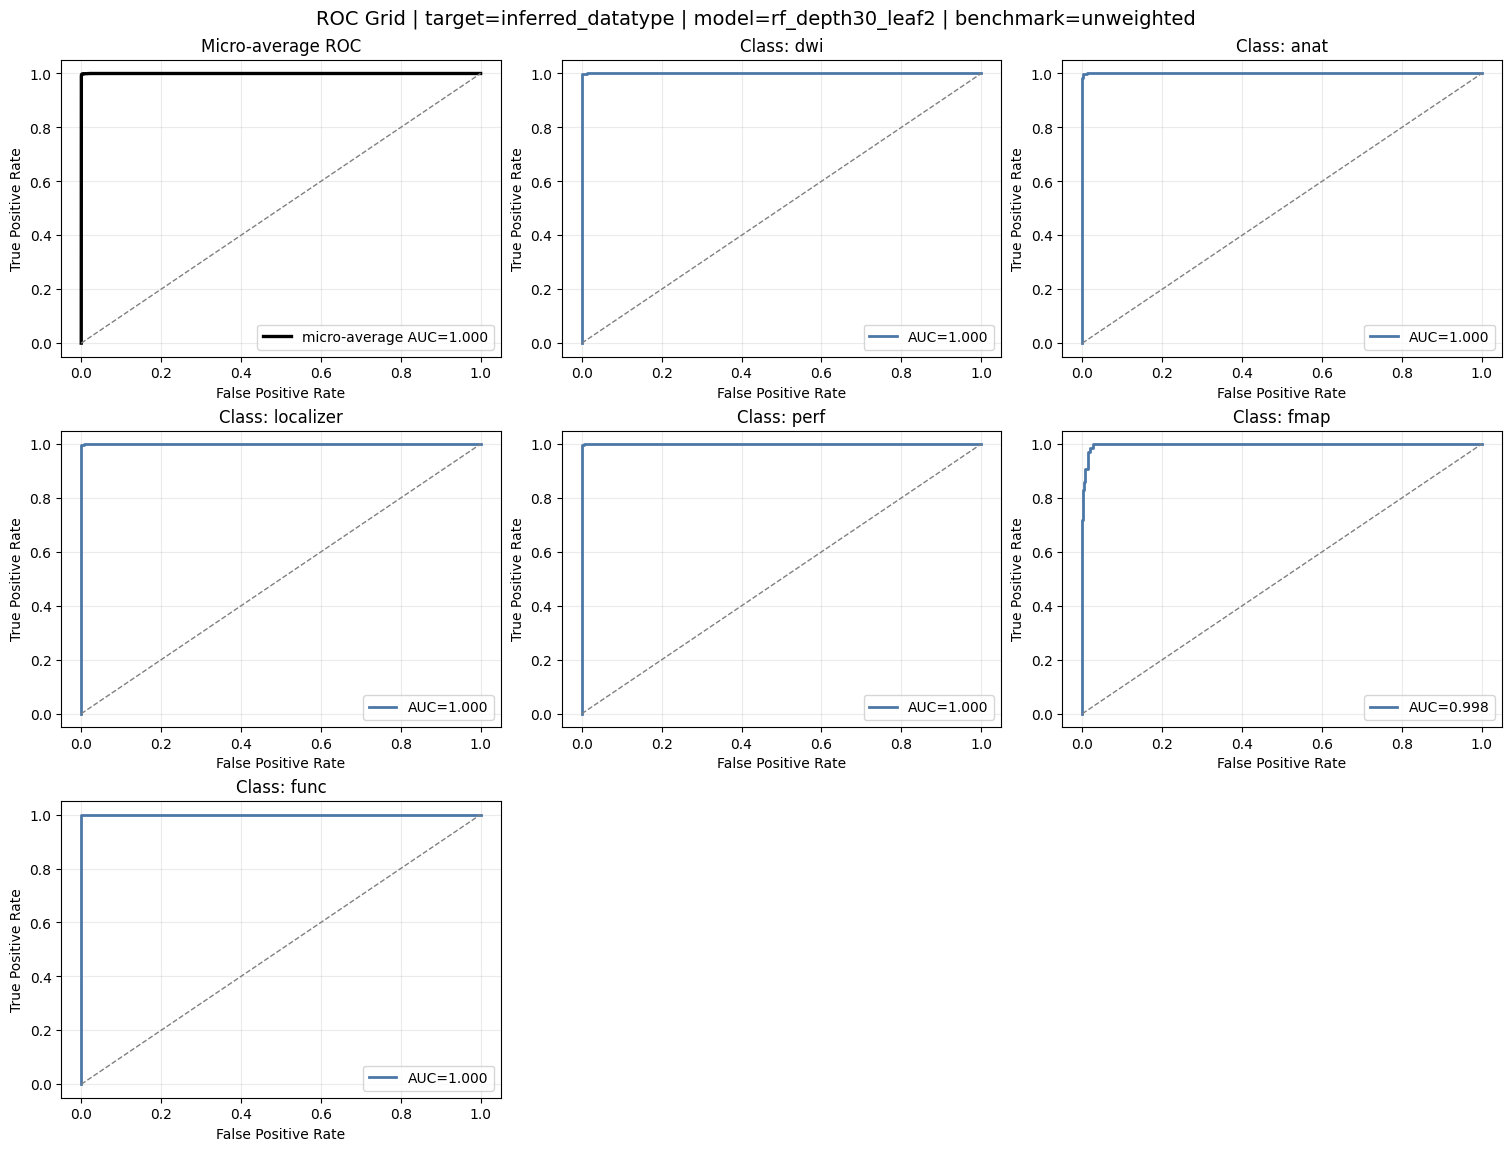

Saved ROC grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/roc/roc_grid_inferred_datatype_rf_depth30_leaf2_unweighted.png
Evaluating ROC using model=extra_trees_depth35_leaf2, target=inferred_joint_label, benchmark=unweighted


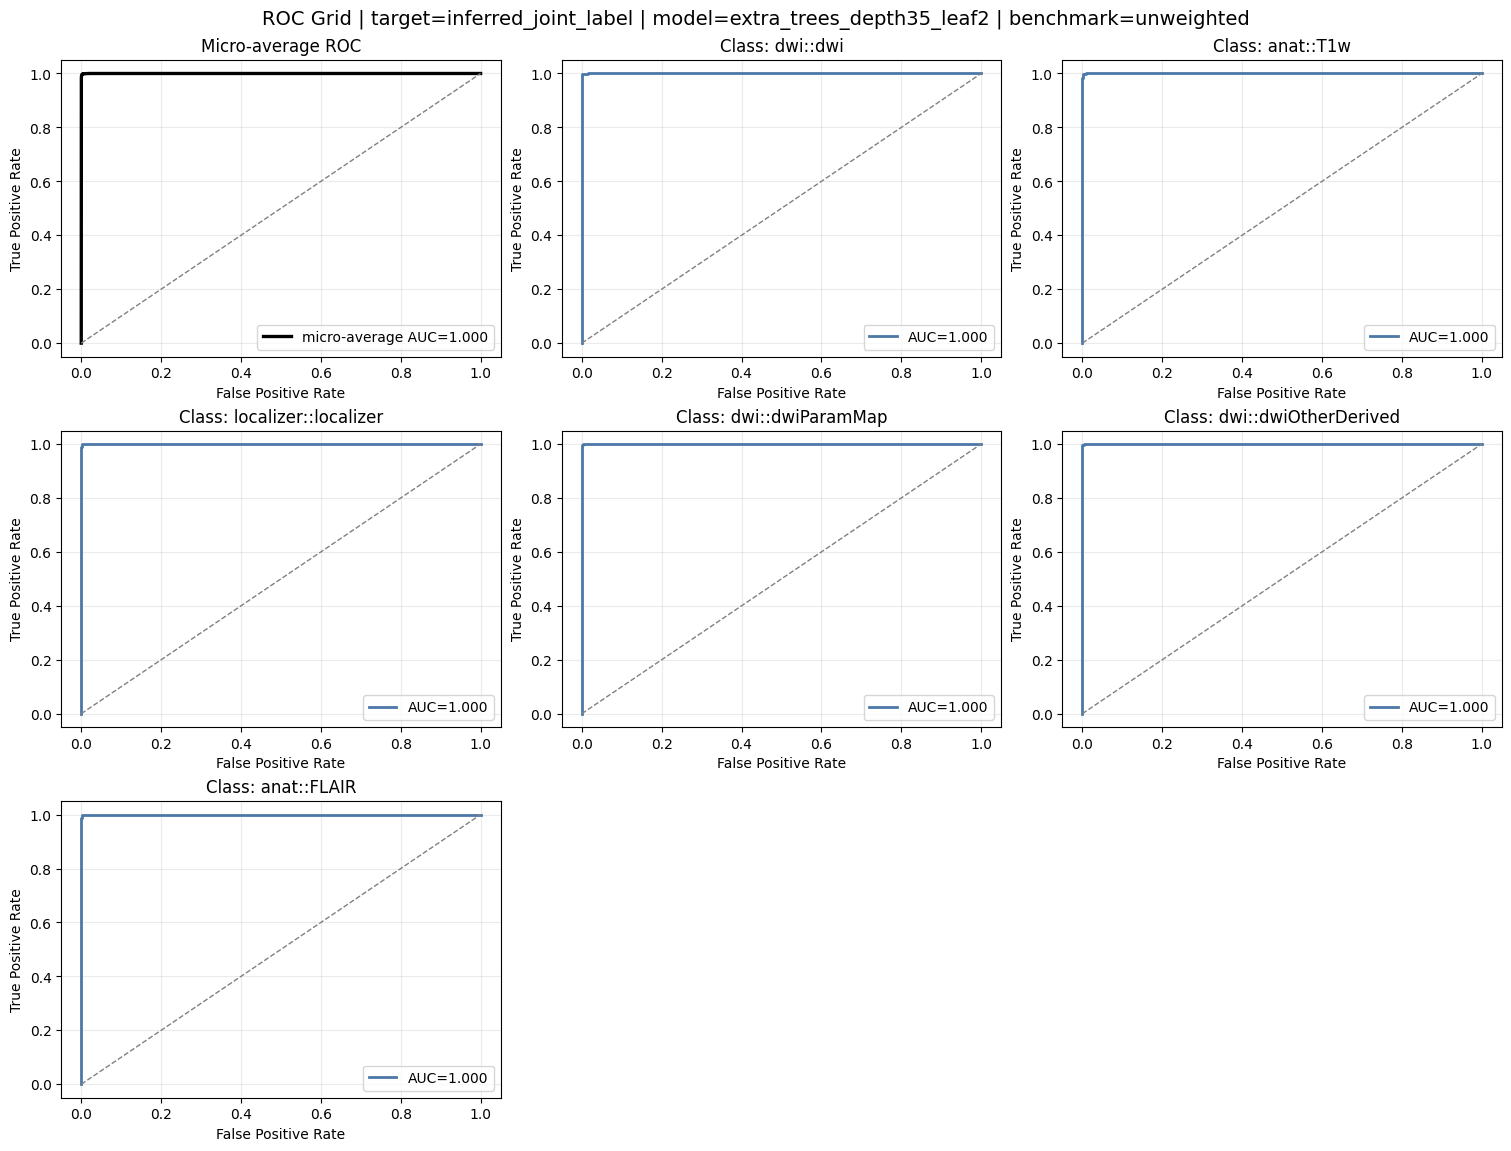

Saved ROC grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/roc/roc_grid_inferred_joint_label_extra_trees_depth35_leaf2_unweighted.png
Evaluating ROC using model=xgboost_depth8, target=inferred_suffix, benchmark=unweighted


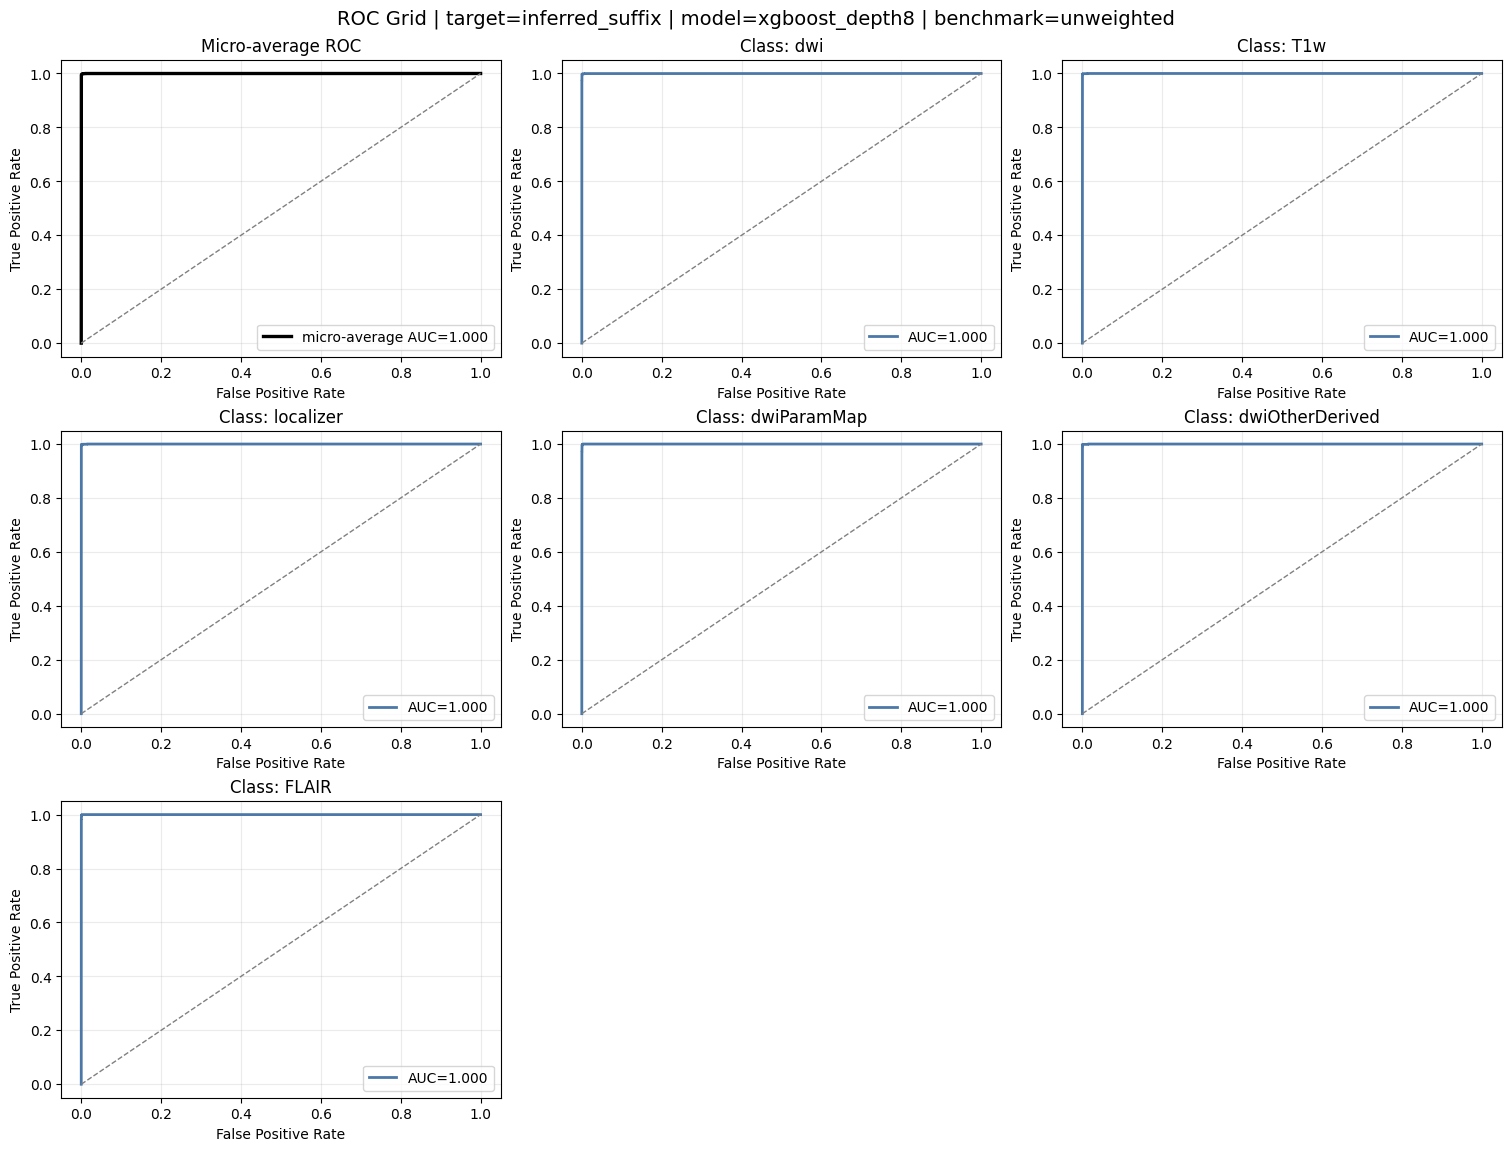

Saved ROC grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/roc/roc_grid_inferred_suffix_xgboost_depth8_unweighted.png


[PosixPath('/Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/roc/roc_grid_inferred_datatype_rf_depth30_leaf2_unweighted.png'),
 PosixPath('/Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/roc/roc_grid_inferred_joint_label_extra_trees_depth35_leaf2_unweighted.png'),
 PosixPath('/Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/roc/roc_grid_inferred_suffix_xgboost_depth8_unweighted.png')]

In [17]:
prepared_sets_map_for_roc: dict[str, dict[str, object]] = {
    "unweighted": {split_name: split for split_name, split in unweighted_sets.items()},
    "weighted_min_confidence": {
        split_name: split for split_name, split in weighted_sets.items()
    },
}

plot_multiclass_roc_for_best_models(
    results_df=model_results,
    prepared_sets_map=prepared_sets_map_for_roc,
)

## Precision-Recall Curves For Best Models

For imbalanced targets, Precision-Recall (PR) curves are usually more informative than ROC curves because they focus on positive-class retrieval quality.

This section uses the same best model per target and plots:
- micro-average PR (overall)
- class-wise PR curves for the most frequent classes
- baseline prevalence lines for context

,target,benchmark,model,test_f1_macro,test_auc_macro_ovr
0,inferred_datatype,unweighted,rf_depth30_leaf2,0.917184,0.999597
1,inferred_joint_label,unweighted,extra_trees_depth35_leaf2,0.834270,0.999799
2,inferred_suffix,unweighted,xgboost_depth8,0.854616,0.999559


Evaluating Precision-Recall using model=rf_depth30_leaf2, target=inferred_datatype, benchmark=unweighted


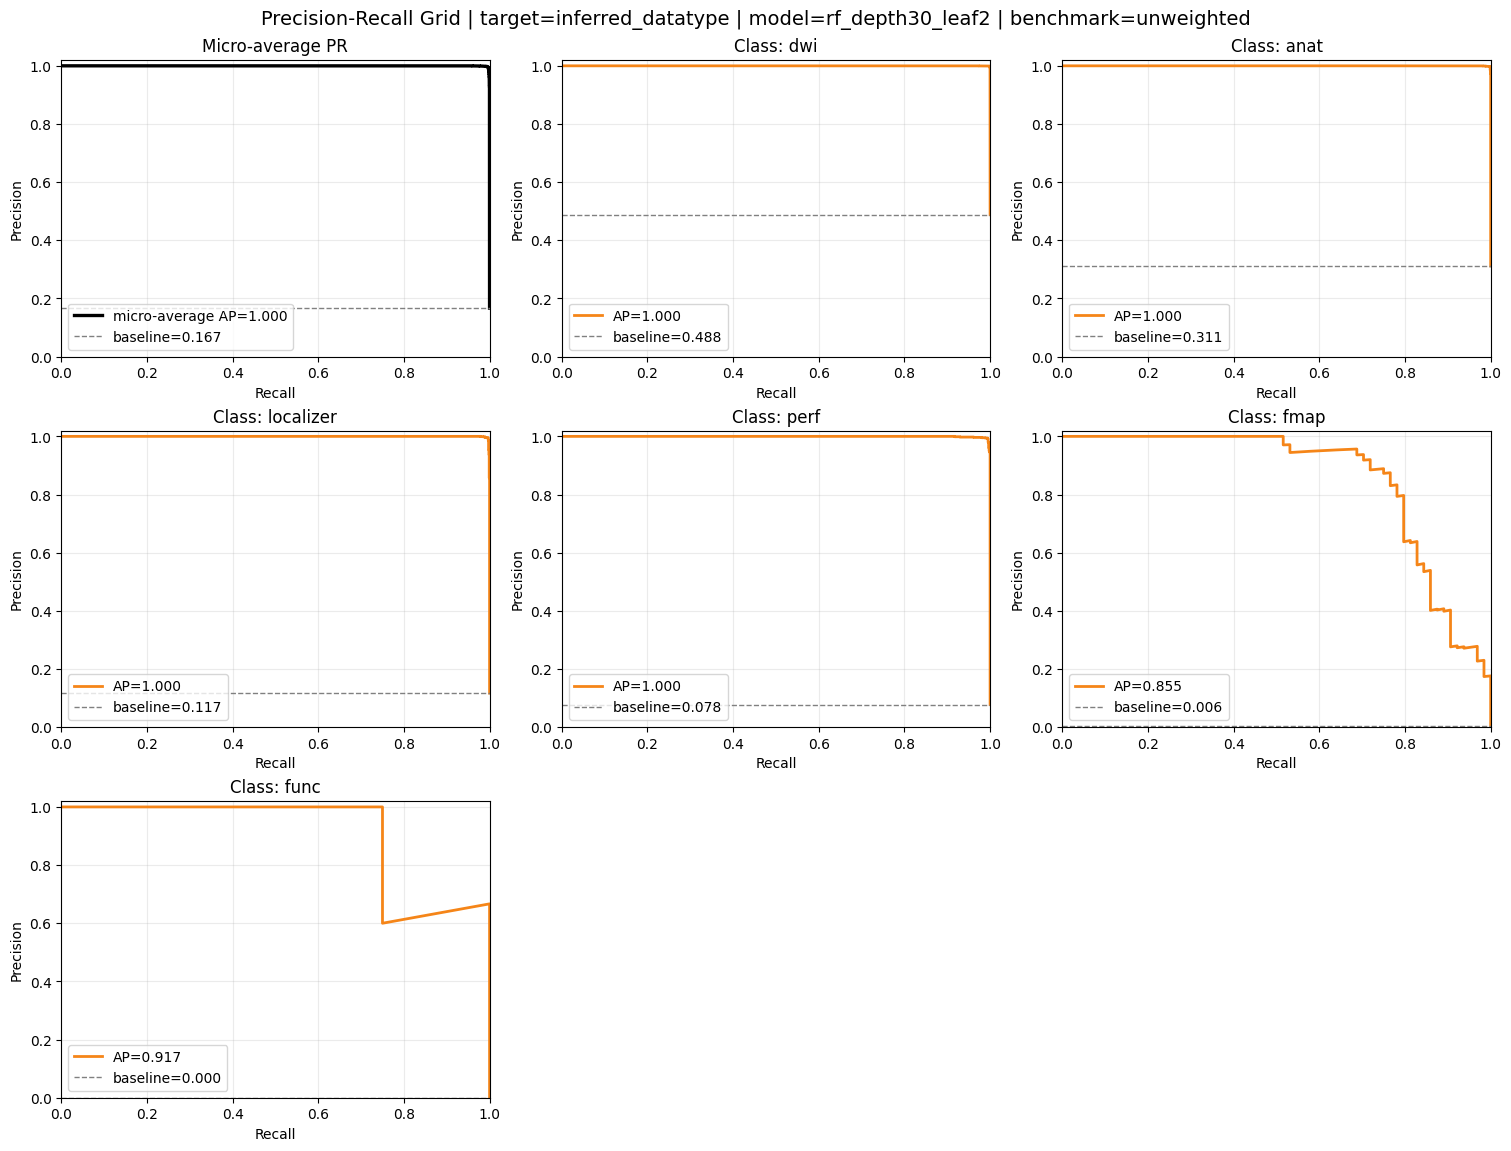

Saved PR grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/precision_recall/pr_grid_inferred_datatype_rf_depth30_leaf2_unweighted.png
Evaluating Precision-Recall using model=extra_trees_depth35_leaf2, target=inferred_joint_label, benchmark=unweighted


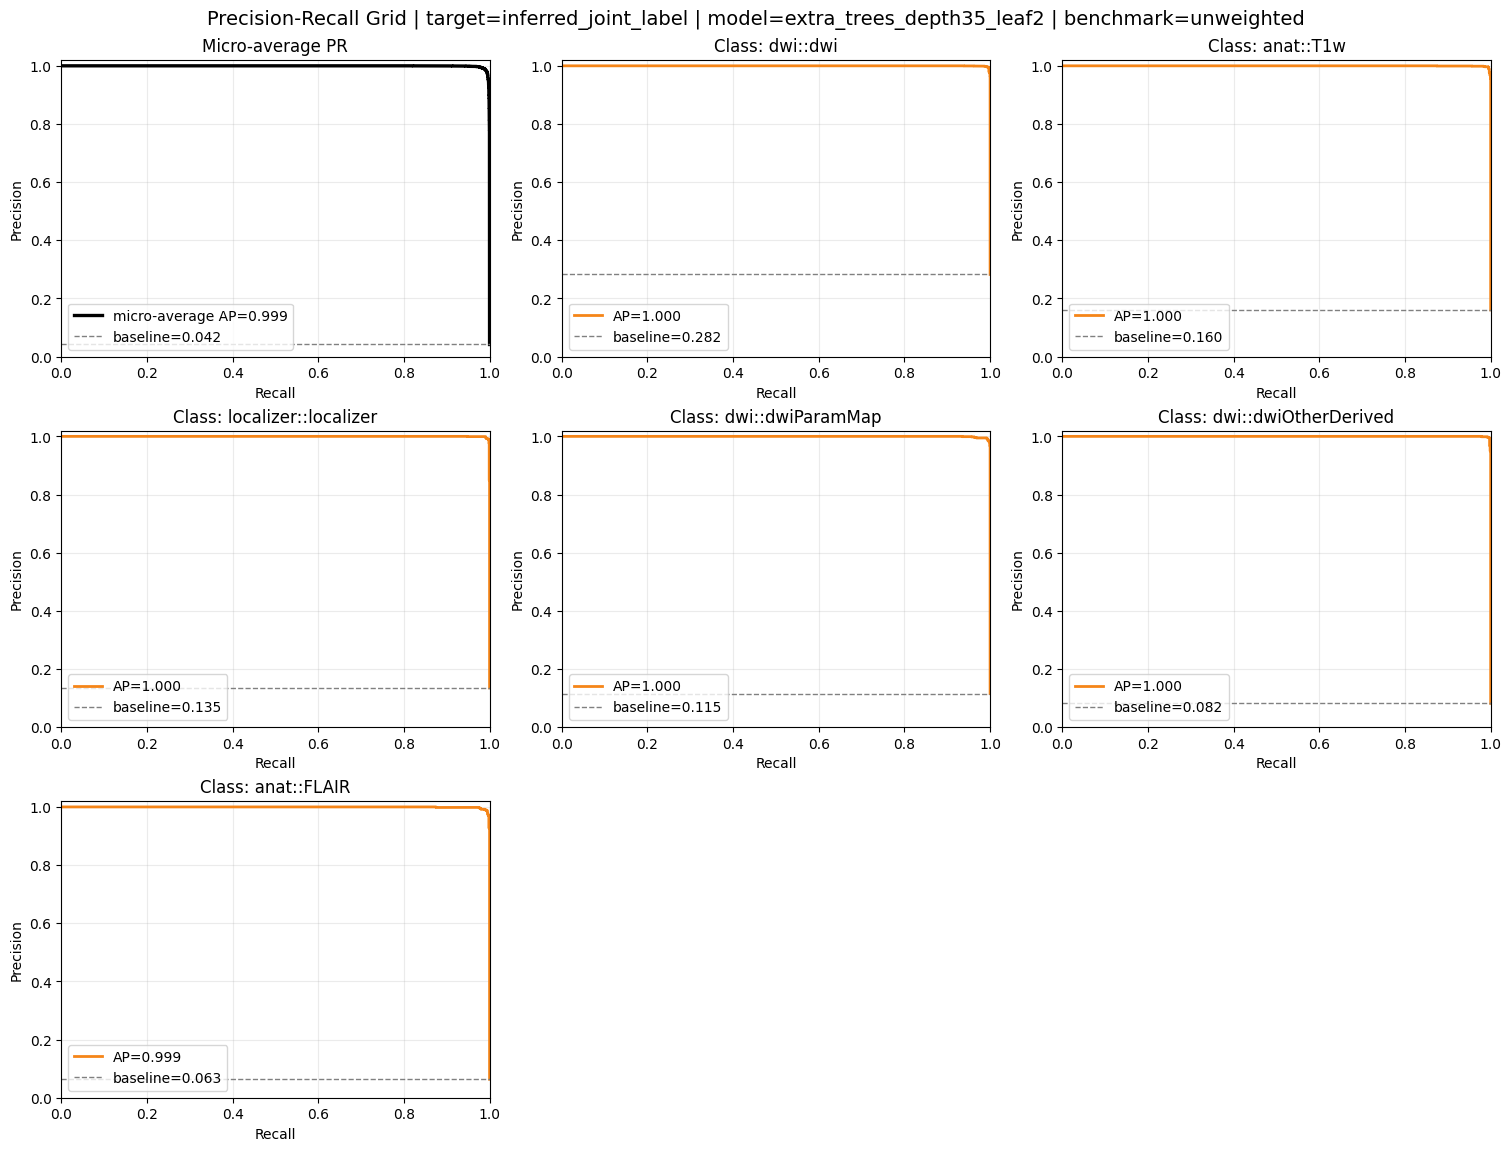

Saved PR grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/precision_recall/pr_grid_inferred_joint_label_extra_trees_depth35_leaf2_unweighted.png
Evaluating Precision-Recall using model=xgboost_depth8, target=inferred_suffix, benchmark=unweighted


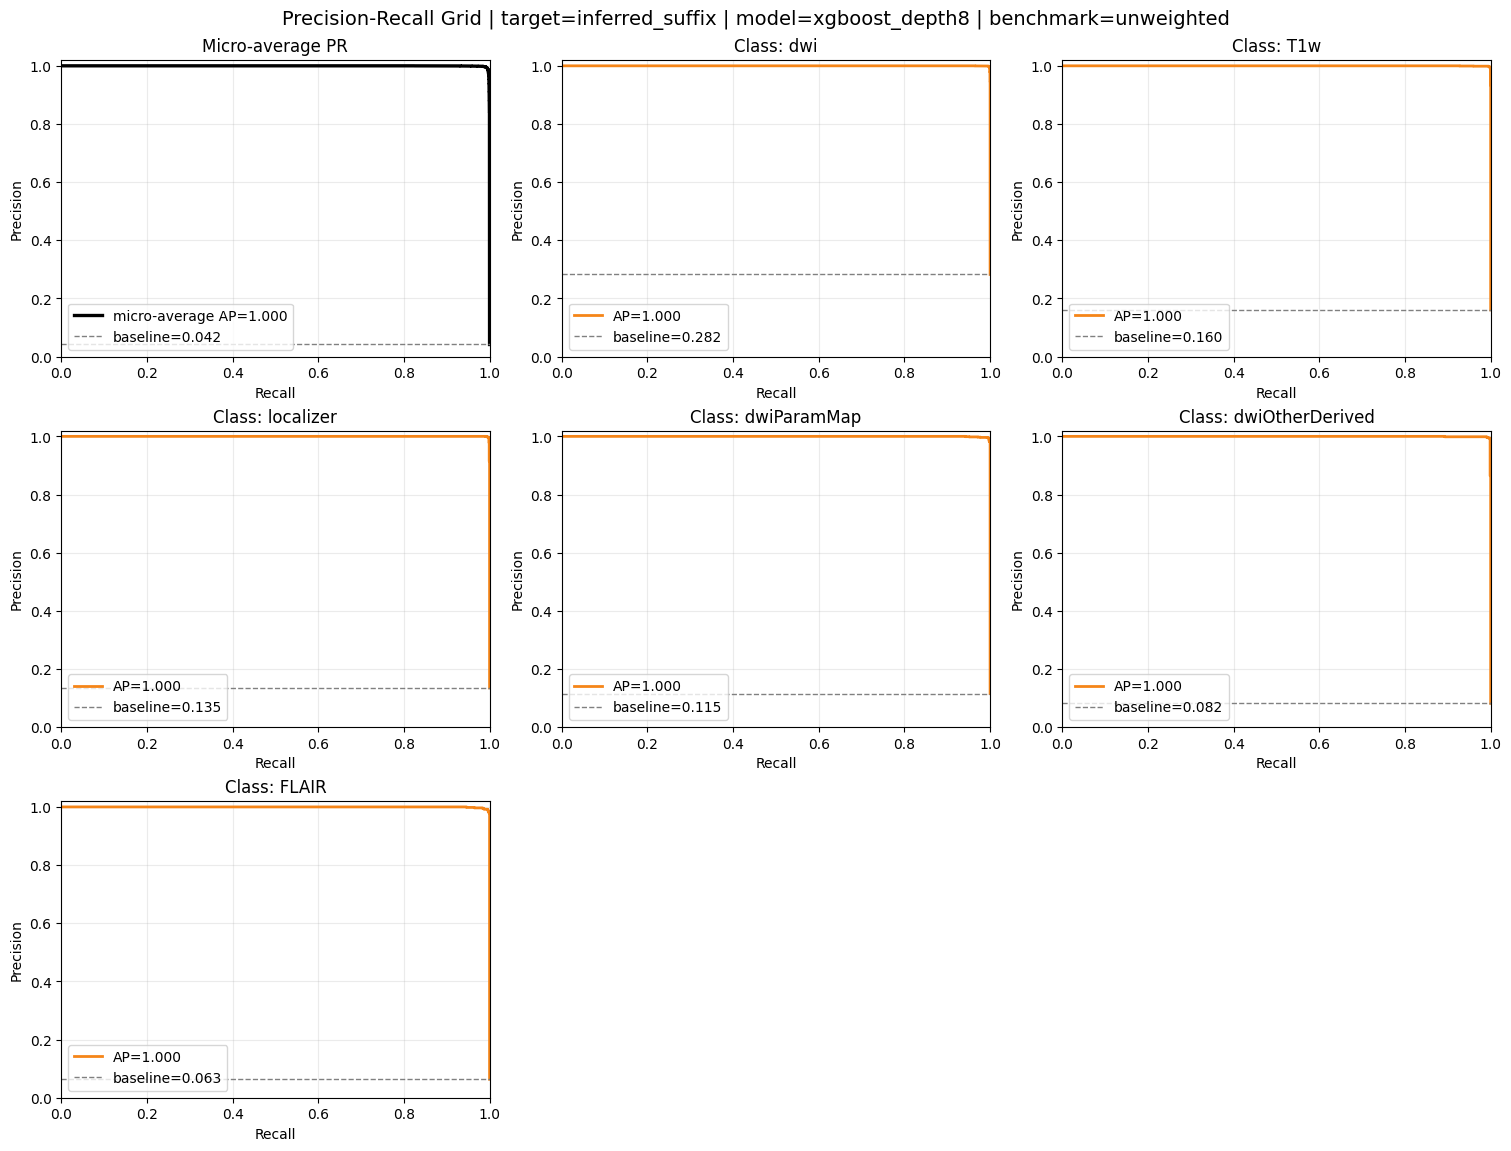

Saved PR grid: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/precision_recall/pr_grid_inferred_suffix_xgboost_depth8_unweighted.png


[PosixPath('/Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/precision_recall/pr_grid_inferred_datatype_rf_depth30_leaf2_unweighted.png'),
 PosixPath('/Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/precision_recall/pr_grid_inferred_joint_label_extra_trees_depth35_leaf2_unweighted.png'),
 PosixPath('/Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/precision_recall/pr_grid_inferred_suffix_xgboost_depth8_unweighted.png')]

In [18]:
prepared_sets_map_for_pr: dict[str, dict[str, object]] = {
    "unweighted": {split_name: split for split_name, split in unweighted_sets.items()},
    "weighted_min_confidence": {
        split_name: split for split_name, split in weighted_sets.items()
    },
}

plot_multiclass_pr_for_best_models(
    results_df=model_results,
    prepared_sets_map=prepared_sets_map_for_pr,
)

### What These ROC Grids Show

Each panel shows one-vs-rest discrimination quality for the selected best model per target.

Quick read:
- Curves closer to the top-left are better.
- The micro-average panel summarizes aggregate ranking quality across classes.
- Class-level ROC panels reveal whether minority or confusing classes lag behind even when micro-average looks strong.

In [19]:
diag_view = (
    best_diagnostics[[
        "target",
        "benchmark",
        "model",
        "val_f1_macro",
        "test_f1_macro",
        "f1_gap_val_minus_test",
        "val_auc_macro_ovr",
        "test_auc_macro_ovr",
        "auc_gap_val_minus_test",
        "test_balanced_accuracy",
        "test_top2_accuracy",
        "test_top3_accuracy",
        "overfit_flag",
        "low_perf_flag",
    ]]
    .sort_values(["target", "test_f1_macro"], ascending=[True, False])
)

with pd.option_context("display.max_rows", 50, "display.max_columns", 20, "display.width", 200):
    display(diag_view)

overall = {
    "rows": len(model_results),
    "targets": sorted(model_results["target"].dropna().unique().tolist()),
    "max_test_f1": float(model_results["test_f1_macro"].max()),
    "max_test_auc": float(model_results["test_auc_macro_ovr"].dropna().max()),
    "overfit_cases": int(best_diagnostics["overfit_flag"].sum()),
    "low_perf_cases": int(best_diagnostics["low_perf_flag"].sum()),
}
print(overall)

,target,benchmark,model,val_f1_macro,test_f1_macro,f1_gap_val_minus_test,val_auc_macro_ovr,test_auc_macro_ovr,auc_gap_val_minus_test,test_balanced_accuracy,test_top2_accuracy,test_top3_accuracy,overfit_flag,low_perf_flag
0,inferred_datatype,unweighted,rf_depth30_leaf2,0.954567,0.917184,0.037383,0.999782,0.999597,0.000185,0.940864,0.999017,0.999464,False,False
1,inferred_datatype,weighted_min_confidence,rf_depth30_leaf2,0.958008,0.914922,0.043085,0.999791,0.999537,0.000255,0.938168,0.998928,0.999732,False,False
2,inferred_joint_label,unweighted,extra_trees_depth35_leaf2,0.837352,0.834270,0.003082,0.999818,0.999799,0.000020,0.803724,0.997427,0.998868,False,False
3,inferred_joint_label,weighted_min_confidence,extra_trees_depth25,0.850464,0.826527,0.023936,0.999728,0.999797,-0.000069,0.818212,0.997941,0.998765,False,False
4,inferred_suffix,unweighted,xgboost_depth8,0.828246,0.854616,-0.026370,0.999758,0.999559,0.000199,0.832683,0.998353,0.999177,False,False
5,inferred_suffix,weighted_min_confidence,extra_trees_depth25_balanced,0.881893,0.826426,0.055467,0.999662,0.999757,-0.000095,0.821875,0.997633,0.998765,True,False


{'rows': 66, 'targets': ['inferred_datatype', 'inferred_joint_label', 'inferred_suffix'], 'max_test_f1': 0.9171838622043205, 'max_test_auc': 0.9998593699973194, 'overfit_cases': 1, 'low_perf_cases': 0}


,target,class,count,fraction,imbalance_ratio_vs_max
0,inferred_datatype,dwi,21768,0.478691,1.000000
1,inferred_datatype,anat,13768,0.302766,1.581058
2,inferred_datatype,localizer,6162,0.135506,3.532619
3,inferred_datatype,perf,3547,0.078001,6.137017
4,inferred_datatype,fmap,217,0.004772,100.313364
5,inferred_datatype,func,12,0.000264,1814.000000
34,inferred_joint_label,dwi::dwi,12873,0.283085,1.000000
35,inferred_joint_label,anat::T1w,6973,0.153340,1.846121
36,inferred_joint_label,localizer::localizer,6162,0.135506,2.089094
37,inferred_joint_label,dwi::dwiParamMap,5239,0.115209,2.457148


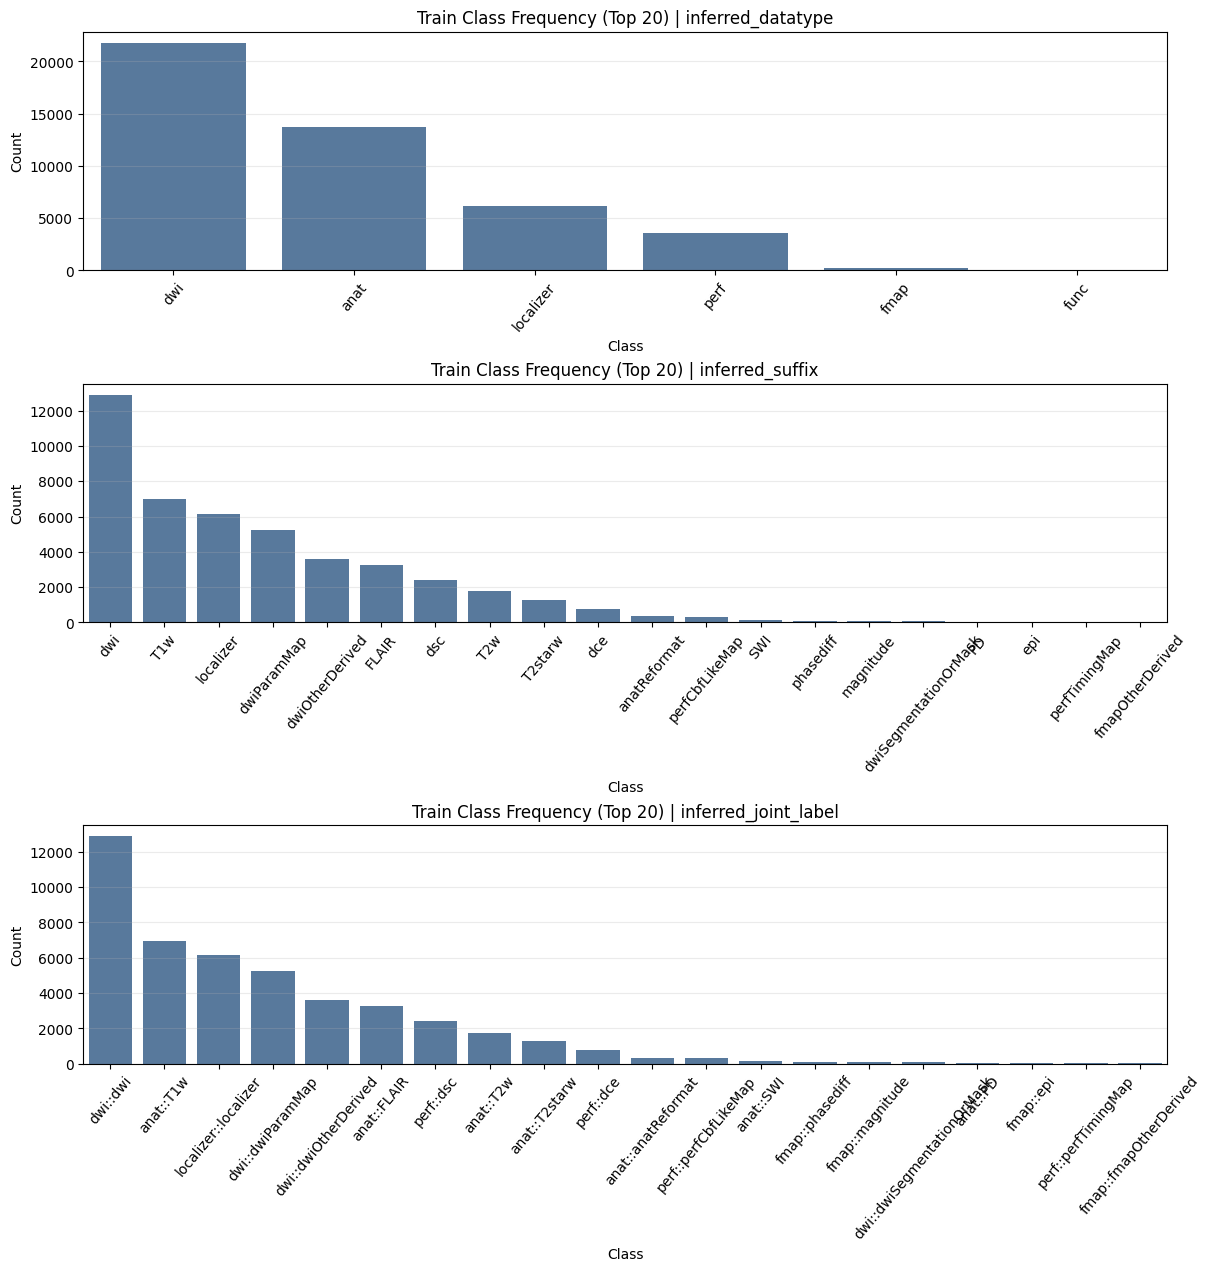

Saved imbalance plot: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/analysis/class_imbalance_top20.png
Explanation: long-tail class imbalance is present where several classes have far fewer samples than dominant classes. Balanced models and macro metrics are therefore important.


,target,benchmark,model,test_f1_macro,test_balanced_accuracy
0,inferred_datatype,unweighted,rf_depth30_leaf2,0.917184,0.940864
1,inferred_joint_label,unweighted,extra_trees_depth35_leaf2,0.834270,0.803724
2,inferred_suffix,unweighted,xgboost_depth8,0.854616,0.832683


,label,precision,recall,f1-score,support
3,func,0.571429,1.000000,0.727273,4.0
2,fmap,1.000000,0.656250,0.792453,64.0
5,perf,0.987443,0.995397,0.991404,869.0
4,localizer,0.995416,0.995416,0.995416,1309.0
0,anat,0.996279,0.998852,0.997564,3485.0
1,dwi,0.998719,0.999268,0.998993,5461.0


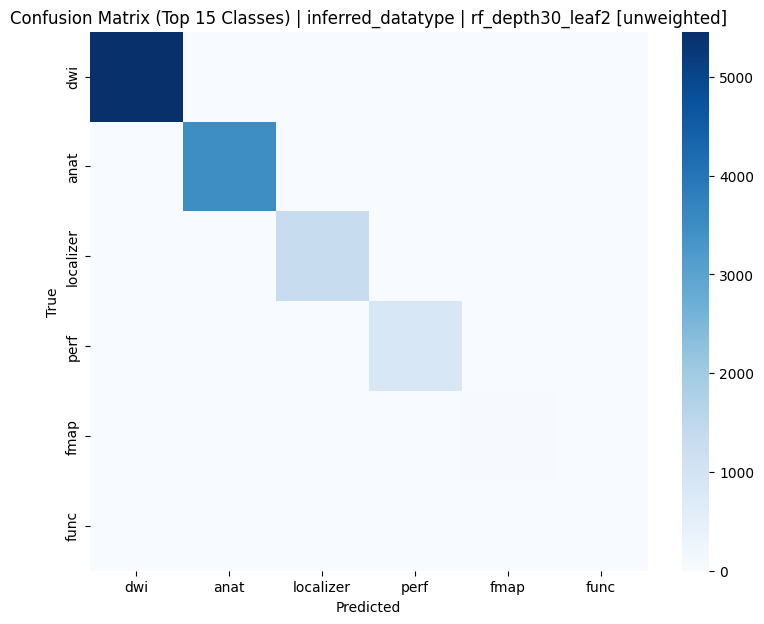

Saved confusion matrix: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/analysis/confusion_top15_inferred_datatype_rf_depth30_leaf2_unweighted.png
Explanation: rows with heavy off-diagonal mass indicate class confusion; low-f1 classes in the table are primary error hotspots to target.


,label,precision,recall,f1-score,support
13,fmap::fmapSusceptibilityOrPhaseMap,0.000000,0.000000,0.000000,1.0
22,perf::perfCbvLikeMap,0.000000,0.000000,0.000000,3.0
23,perf::perfTimingMap,1.000000,0.200000,0.333333,5.0
6,anat::anatReformat,0.979167,0.546512,0.701493,86.0
11,fmap::epi,1.000000,0.571429,0.727273,7.0
1,anat::PD,1.000000,0.625000,0.769231,8.0
14,fmap::magnitude,0.944444,0.809524,0.871795,21.0
10,dwi::dwiSegmentationOrMask,1.000000,0.785714,0.880000,14.0
15,fmap::phasediff,1.000000,0.833333,0.909091,12.0
2,anat::SWI,0.888889,1.000000,0.941176,24.0


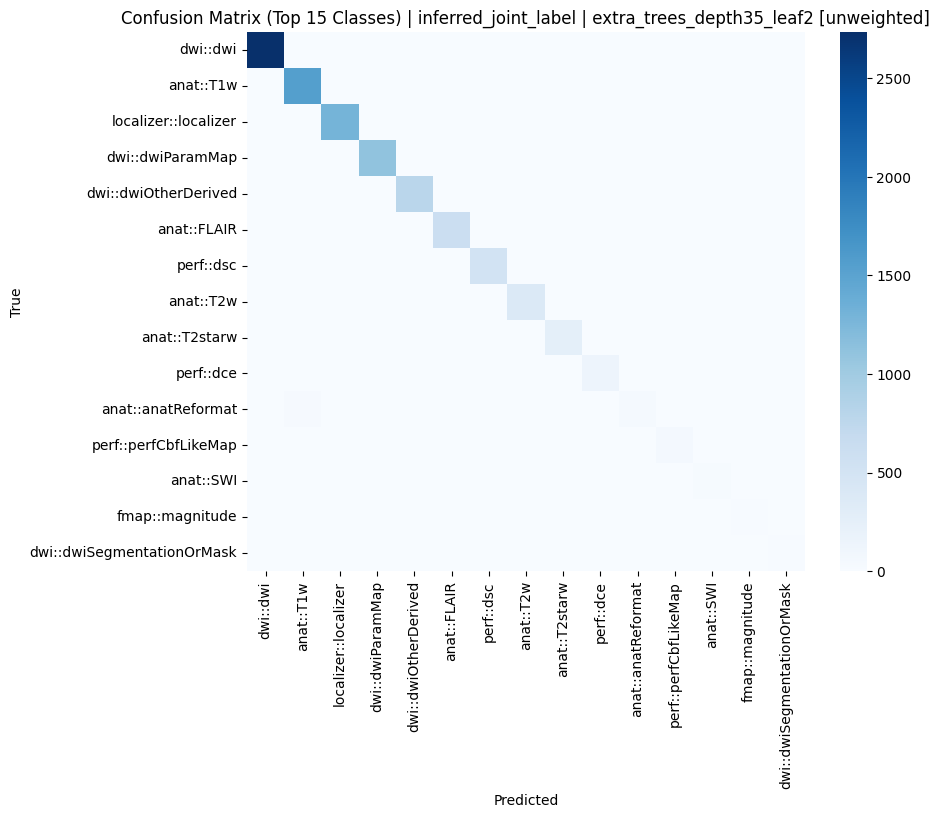

Saved confusion matrix: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/analysis/confusion_top15_inferred_joint_label_extra_trees_depth35_leaf2_unweighted.png
Explanation: rows with heavy off-diagonal mass indicate class confusion; low-f1 classes in the table are primary error hotspots to target.


,label,precision,recall,f1-score,support
16,fmapSusceptibilityOrPhaseMap,0.000000,0.000000,0.000000,1.0
22,perfTimingMap,1.000000,0.200000,0.333333,5.0
14,epi,0.500000,0.285714,0.363636,7.0
21,perfCbvLikeMap,1.000000,0.333333,0.500000,3.0
1,PD,1.000000,0.625000,0.769231,8.0
13,dwiSegmentationOrMask,0.923077,0.857143,0.888889,14.0
19,magnitude,0.947368,0.857143,0.900000,21.0
6,anatReformat,0.939024,0.895349,0.916667,86.0
23,phasediff,0.923077,1.000000,0.960000,12.0
2,SWI,0.923077,1.000000,0.960000,24.0


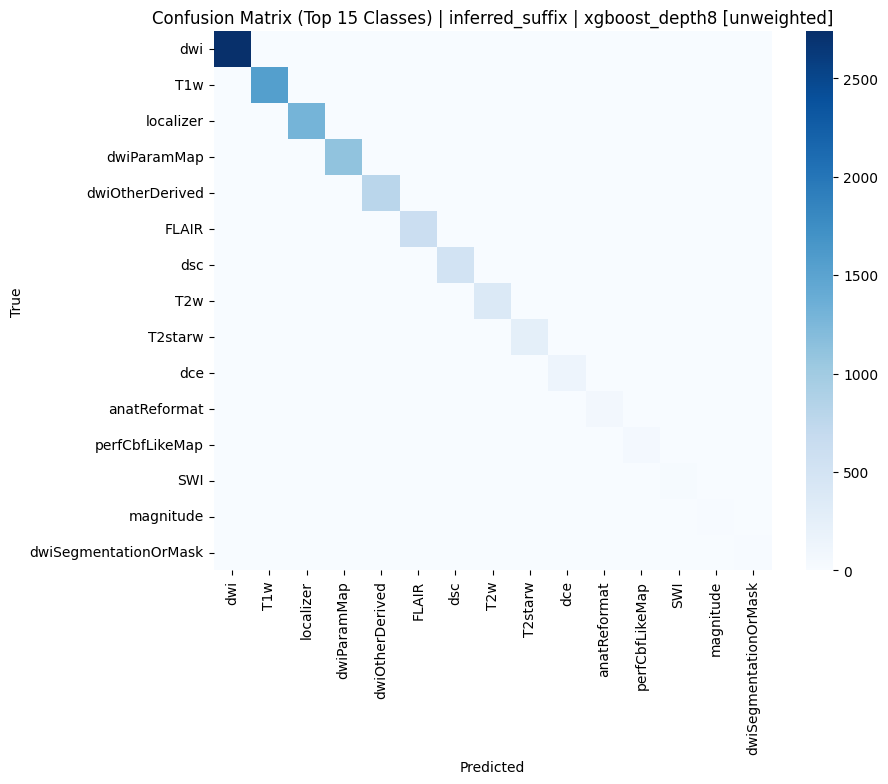

Saved confusion matrix: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/analysis/confusion_top15_inferred_suffix_xgboost_depth8_unweighted.png
Explanation: rows with heavy off-diagonal mass indicate class confusion; low-f1 classes in the table are primary error hotspots to target.


,feature,missing_rate,variance,mi_inferred_datatype,mi_inferred_suffix,mi_inferred_joint_label,mi_max
9,echo_time,0.0,6.394561e+03,0.957316,1.589719,1.589719,1.589719
65,tr_te_ratio,0.0,1.659348e+05,1.008002,1.589170,1.589170,1.589170
75,log_echo_time,0.0,2.085023e+00,0.959419,1.588764,1.588764,1.588764
67,slices_per_second,0.0,9.142846e+07,0.924297,1.579543,1.579543,1.579543
58,voxel_volume,0.0,4.498079e+02,0.948145,1.551399,1.551399,1.551399
74,log_repetition_time,0.0,7.774210e+00,0.913943,1.521857,1.521857,1.521857
77,log_scan_duration_seconds,0.0,9.721264e-01,0.912948,1.520807,1.520807,1.520807
62,scan_duration_seconds,0.0,3.488876e+02,0.912934,1.517835,1.517835,1.517835
8,repetition_time,0.0,1.118465e+07,0.911348,1.516083,1.516083,1.516083
61,volumes_per_second,0.0,4.262923e+05,0.904427,1.510381,1.510381,1.510381


,feature,missing_rate,variance,mi_inferred_datatype,mi_inferred_suffix,mi_inferred_joint_label,mi_max
179,model_verio_dot,0.0,0.000549,0.000085,0.0,0.0,0.000085
145,model_contouring,0.0,0.000901,0.000000,0.0,0.0,0.000000
143,model_biograph_mmr,0.0,0.001296,0.000000,0.0,0.0,0.000000
177,model_triotim,0.0,0.000945,0.000000,0.0,0.0,0.000000
321,contrast_agent_y y,0.0,0.000725,0.000000,0.0,0.0,0.000000
27,is_localizer,0.0,0.000022,0.000000,0.0,0.0,0.000000
298,contrast_agent_7.8 gad,0.0,0.000308,0.000000,0.0,0.0,0.000000
178,model_verio,0.0,0.003135,0.000000,0.0,0.0,0.000000
320,contrast_agent_y gad,0.0,0.001098,0.000000,0.0,0.0,0.000000
154,model_magnetom altea,0.0,0.001537,0.000000,0.0,0.0,0.000000


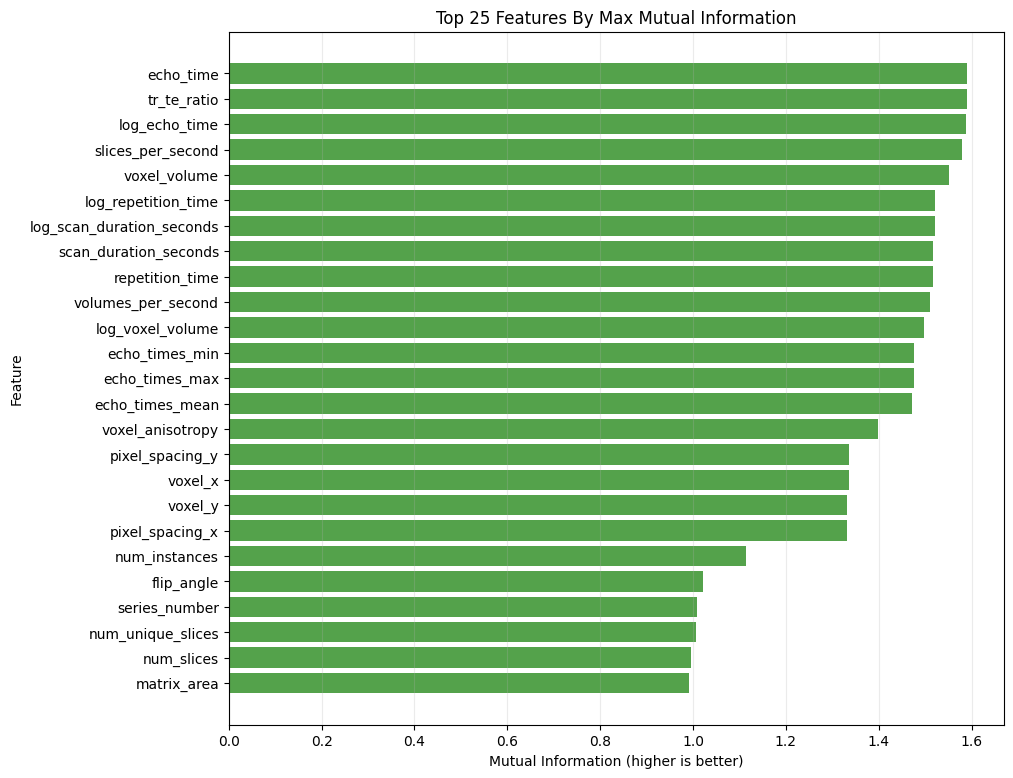

Saved feature usefulness plot: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/analysis/feature_importance_mi_top25.png
Explanation: features near zero MI and near-zero variance are weaker candidates; dropping these first can reduce feature count with limited signal loss.
{'total_features': 519, 'drop_candidates': 22, 'candidate_drop_pct': 0.04238921001926782}


In [20]:
analysis_plot_dir = PROJECT_PLOTS_DIR / "analysis"
analysis_plot_dir.mkdir(parents=True, exist_ok=True)

# 1) Class-imbalance analysis on train split
train_split = unweighted_sets["train"]
imbalance_rows = []
for target in TARGETS:
    counts = _target_series_from_y(train_split.y, target).value_counts(dropna=False)
    total = counts.sum()
    max_count = counts.max() if len(counts) else 1
    for cls, count in counts.items():
        imbalance_rows.append(
            {
                "target": target,
                "class": str(cls),
                "count": int(count),
                "fraction": float(count / total) if total else 0.0,
                "imbalance_ratio_vs_max": float(max_count / max(1, count)),
            }
        )
imbalance_df = pd.DataFrame(imbalance_rows)
display(imbalance_df.sort_values(["target", "count"], ascending=[True, False]).head(25))

fig, axes = plt.subplots(nrows=len(TARGETS), ncols=1, figsize=(12, 4.2 * len(TARGETS)), constrained_layout=True)
if len(TARGETS) == 1:
    axes = [axes]
for ax, target in zip(axes, TARGETS):
    sub = imbalance_df[imbalance_df["target"] == target].sort_values("count", ascending=False).head(20)
    sns.barplot(data=sub, x="class", y="count", ax=ax, color="#4C78A8")
    ax.set_title(f"Train Class Frequency (Top 20) | {target}")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=50)
    ax.grid(axis="y", alpha=0.25)
imbalance_plot_path = analysis_plot_dir / "class_imbalance_top20.png"
fig.savefig(imbalance_plot_path, dpi=170, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved imbalance plot: {imbalance_plot_path}")
print("Explanation: long-tail class imbalance is present where several classes have far fewer samples than dominant classes. Balanced models and macro metrics are therefore important.")

# 2) Per-class error analysis for best model per target
best_per_target = (
    best_diagnostics.sort_values(["target", "test_f1_macro"], ascending=[True, False])
    .groupby("target", as_index=False)
    .first()
)
display(best_per_target[["target", "benchmark", "model", "test_f1_macro", "test_balanced_accuracy"]])

for _, row in best_per_target.iterrows():
    target = row["target"]
    benchmark = row["benchmark"]
    model_name = row["model"]
    prepared_sets = unweighted_sets if benchmark == "unweighted" else weighted_sets
    use_sample_weight = benchmark == "weighted_min_confidence"

    model, fit_info, X_test, y_test, class_labels = fit_model_for_target(
        prepared_sets=prepared_sets,
        target=target,
        model_name=model_name,
        use_sample_weight=use_sample_weight,
    )
    y_pred, _ = _predict_model(model, fit_info, X_test, class_labels)

    y_eval = y_test.dropna().astype("string")
    y_eval = y_eval[y_eval.isin(class_labels)]
    y_pred_eval = y_pred.loc[y_eval.index].astype("string")

    report = classification_report(
        y_eval,
        y_pred_eval,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})
    report_df = report_df[~report_df["label"].isin(["accuracy", "macro avg", "weighted avg"])]
    report_df = report_df.sort_values("f1-score", ascending=True)
    display(report_df.head(15))

    top_classes = y_eval.value_counts().head(15).index.astype("string").tolist()
    cm = confusion_matrix(y_eval, y_pred_eval, labels=top_classes)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, cmap="Blues", ax=ax, xticklabels=top_classes, yticklabels=top_classes)
    ax.set_title(f"Confusion Matrix (Top 15 Classes) | {target} | {model_name} [{benchmark}]")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    cm_path = analysis_plot_dir / f"confusion_top15_{_safe_plot_slug(target)}_{_safe_plot_slug(model_name)}_{_safe_plot_slug(benchmark)}.png"
    fig.savefig(cm_path, dpi=170, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved confusion matrix: {cm_path}")
    print("Explanation: rows with heavy off-diagonal mass indicate class confusion; low-f1 classes in the table are primary error hotspots to target.")

# 3) Feature usefulness / reduction analysis
X_train_num = _to_numeric_ml_matrix(unweighted_sets["train"].X)
missing_rate = X_train_num.isna().mean()
variances = X_train_num.fillna(0.0).var()

feature_scores = pd.DataFrame({
    "feature": X_train_num.columns,
    "missing_rate": missing_rate.reindex(X_train_num.columns).to_numpy(),
    "variance": variances.reindex(X_train_num.columns).to_numpy(),
})

for target in TARGETS:
    y_target = _target_series_from_y(unweighted_sets["train"].y, target)
    valid_mask = y_target.notna()
    X_valid = X_train_num.loc[valid_mask].copy()
    y_valid = y_target.loc[valid_mask].copy()
    X_valid = X_valid.fillna(X_valid.median(numeric_only=True)).fillna(0.0)
    y_codes, _ = pd.factorize(y_valid)
    mi = mutual_info_classif(
        X_valid,
        y_codes,
        discrete_features=False,
        random_state=BENCHMARK_RANDOM_STATE,
    )
    feature_scores[f"mi_{target}"] = mi

mi_cols = [f"mi_{t}" for t in TARGETS]
feature_scores["mi_max"] = feature_scores[mi_cols].max(axis=1)
feature_scores = feature_scores.sort_values("mi_max", ascending=False)

drop_candidates = feature_scores[
    (feature_scores["missing_rate"] > 0.98)
    | (feature_scores["variance"] < 1e-8)
    | (feature_scores["mi_max"] < 1e-4)
]
display(feature_scores.head(25))
display(drop_candidates.head(50))

top_feat = feature_scores.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_feat["feature"], top_feat["mi_max"], color="#54A24B")
ax.set_title("Top 25 Features By Max Mutual Information")
ax.set_xlabel("Mutual Information (higher is better)")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.25)
feature_plot_path = analysis_plot_dir / "feature_importance_mi_top25.png"
fig.savefig(feature_plot_path, dpi=170, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved feature usefulness plot: {feature_plot_path}")
print("Explanation: features near zero MI and near-zero variance are weaker candidates; dropping these first can reduce feature count with limited signal loss.")

reduction_summary = {
    "total_features": int(len(feature_scores)),
    "drop_candidates": int(len(drop_candidates)),
    "candidate_drop_pct": float(len(drop_candidates) / max(1, len(feature_scores))),
}
print(reduction_summary)

## Finalized Model Training (Joint Label Focus)

This final section trains one finalized model configuration without model-family benchmarking:
- model: `xgboost_depth6`
- training mode: confidence-weighted (`weighted_min_confidence` prepared split)
- target: `inferred_joint_label`

Then it performs detailed evaluation and exports artifacts for review.

In [21]:
FINAL_MODEL_NAME = "xgboost_depth6"
FINAL_TARGETS = ["inferred_joint_label"]
FINAL_OUTPUT_DIR = PROJECT_PLOTS_DIR / "finalized_model"
FINAL_METRIC_DIR = FINAL_OUTPUT_DIR / "metrics"
FINAL_CM_DIR = FINAL_OUTPUT_DIR / "confusion"
FINAL_ROC_DIR = FINAL_OUTPUT_DIR / "roc"
FINAL_PR_DIR = FINAL_OUTPUT_DIR / "precision_recall"

for out_dir in [FINAL_OUTPUT_DIR, FINAL_METRIC_DIR, FINAL_CM_DIR, FINAL_ROC_DIR, FINAL_PR_DIR]:
    out_dir.mkdir(parents=True, exist_ok=True)

final_prepared_sets = weighted_sets
X_train_final = _to_numeric_ml_matrix(final_prepared_sets["train"].X)
X_val_final = _to_numeric_ml_matrix(final_prepared_sets["val"].X).reindex(columns=X_train_final.columns, fill_value=0.0)
X_test_final = _to_numeric_ml_matrix(final_prepared_sets["test"].X).reindex(columns=X_train_final.columns, fill_value=0.0)
y_train_final = final_prepared_sets["train"].y
y_val_final = final_prepared_sets["val"].y
y_test_final = final_prepared_sets["test"].y
sample_weight_final = final_prepared_sets["train"].sample_weight.reindex(X_train_final.index).fillna(1.0)

final_models: dict[str, dict[str, object]] = {}
final_eval_rows: list[dict[str, object]] = []

for target in FINAL_TARGETS:
    y_train_target = _target_series_from_y(y_train_final, target)
    y_val_target = _target_series_from_y(y_val_final, target)
    y_test_target = _target_series_from_y(y_test_final, target)
    class_labels = sorted(y_train_target.dropna().unique().tolist())

    model = clone(MODEL_LOOKUP[FINAL_MODEL_NAME])
    fit_info = _fit_model_once(
        model=model,
        model_name=FINAL_MODEL_NAME,
        X_train=X_train_final,
        y_train_target=y_train_target,
        fit_kwargs={"sample_weight": sample_weight_final},
        class_labels=class_labels,
    )

    val_pred, val_proba = _predict_model(model, fit_info, X_val_final, class_labels)
    test_pred, test_proba = _predict_model(model, fit_info, X_test_final, class_labels)

    val_metrics = _evaluate_predictions(y_val_target, val_pred, val_proba, class_labels)
    test_metrics = _evaluate_predictions(y_test_target, test_pred, test_proba, class_labels)

    final_models[target] = {
        "model": model,
        "fit_info": fit_info,
        "class_labels": class_labels,
        "predictions": {
            "val": {"y_true": y_val_target, "y_pred": val_pred, "y_proba": val_proba},
            "test": {"y_true": y_test_target, "y_pred": test_pred, "y_proba": test_proba},
        },
    }

    final_eval_rows.extend(
        [
            {
                "target": target,
                "split": "val",
                "model": FINAL_MODEL_NAME,
                "weighted_training": True,
                "rows": int(len(X_val_final)),
                "classes_in_train": int(len(class_labels)),
                "accuracy": val_metrics["accuracy"],
                "balanced_accuracy": val_metrics["balanced_accuracy"],
                "f1_macro": val_metrics["f1_macro"],
                "auc_macro_ovr": val_metrics["auc_macro_ovr"],
                "log_loss": val_metrics["log_loss"],
                "top2_accuracy": val_metrics["top2_accuracy"],
                "top3_accuracy": val_metrics["top3_accuracy"],
            },
            {
                "target": target,
                "split": "test",
                "model": FINAL_MODEL_NAME,
                "weighted_training": True,
                "rows": int(len(X_test_final)),
                "classes_in_train": int(len(class_labels)),
                "accuracy": test_metrics["accuracy"],
                "balanced_accuracy": test_metrics["balanced_accuracy"],
                "f1_macro": test_metrics["f1_macro"],
                "auc_macro_ovr": test_metrics["auc_macro_ovr"],
                "log_loss": test_metrics["log_loss"],
                "top2_accuracy": test_metrics["top2_accuracy"],
                "top3_accuracy": test_metrics["top3_accuracy"],
            },
        ]
    )

final_eval_df = pd.DataFrame(final_eval_rows).sort_values(["target", "split"])
final_eval_csv = FINAL_METRIC_DIR / "final_model_eval_metrics.csv"
final_eval_df.to_csv(final_eval_csv, index=False)

display(final_eval_df)
print(f"Saved final evaluation metrics: {final_eval_csv}")

,target,split,model,weighted_training,rows,classes_in_train,accuracy,balanced_accuracy,f1_macro,auc_macro_ovr,log_loss,top2_accuracy,top3_accuracy
1,inferred_joint_label,test,xgboost_depth6,True,11622,28,0.995059,0.798312,0.784230,0.999257,0.015919,0.998868,0.999279
0,inferred_joint_label,val,xgboost_depth6,True,9773,28,0.995805,0.846417,0.838321,0.999810,0.018381,0.998874,0.999488


Saved final evaluation metrics: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/finalized_model/metrics/final_model_eval_metrics.csv


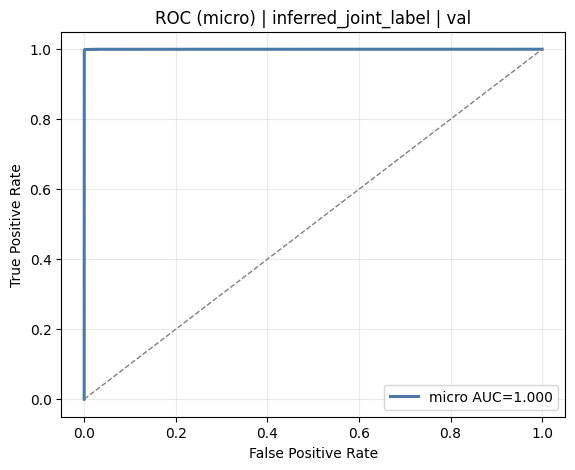

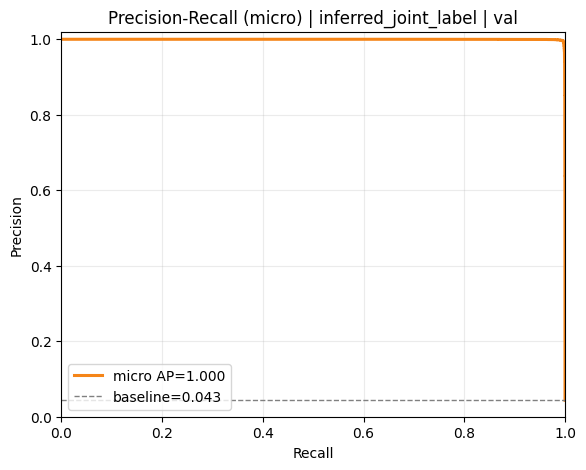

,label,precision,recall,f1-score,support
13,fmap::fmapSusceptibilityOrPhaseMap,0.000000,0.000000,0.000000,1.000000
17,func::funcStatMap,0.000000,0.000000,0.000000,3.000000
22,perf::perfCbvLikeMap,0.000000,0.000000,0.000000,3.000000
23,perf::perfTimingMap,0.333333,0.400000,0.363636,5.000000
16,func::bold,0.250000,1.000000,0.400000,1.000000
11,fmap::epi,0.800000,0.571429,0.666667,7.000000
25,macro avg,0.795281,0.798312,0.784230,9715.000000
12,fmap::fmapOtherDerived,1.000000,0.666667,0.800000,3.000000
1,anat::PD,1.000000,0.750000,0.857143,8.000000
14,fmap::magnitude,0.904762,0.904762,0.904762,21.000000


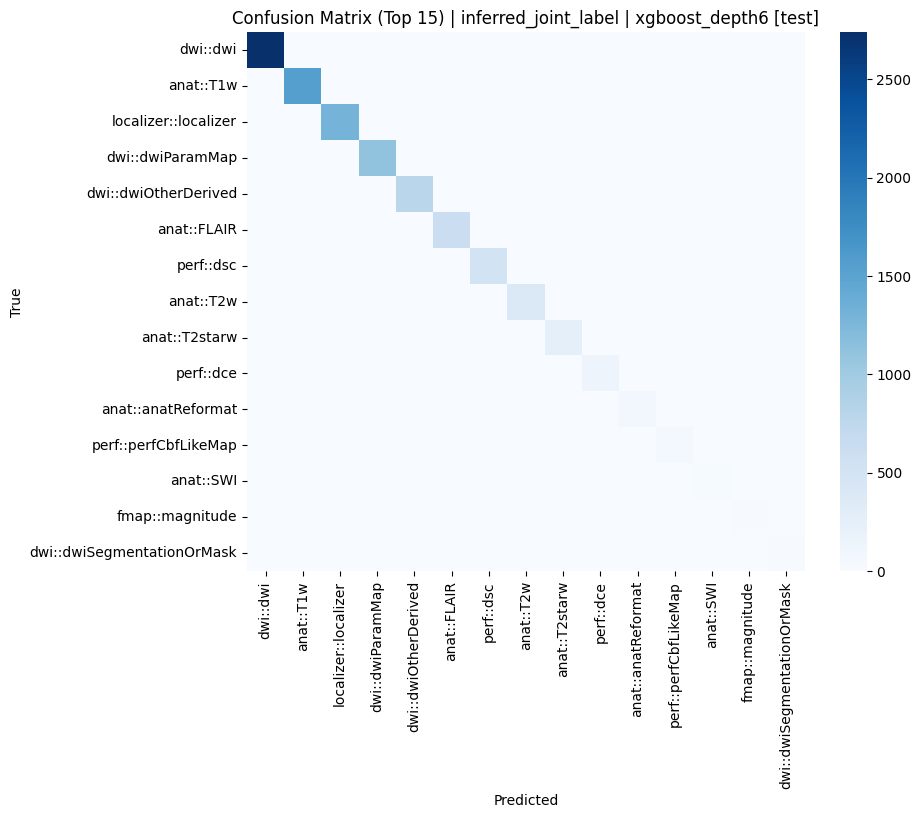

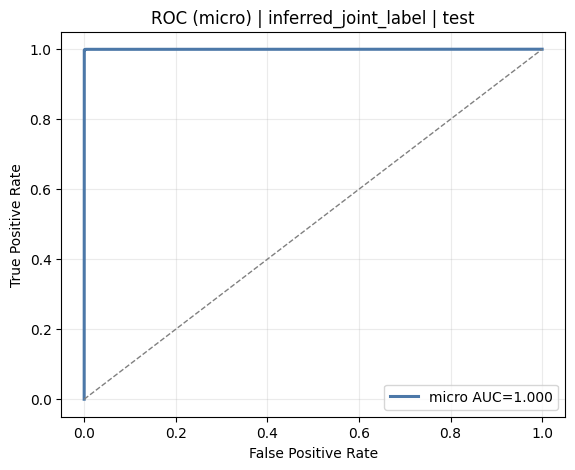

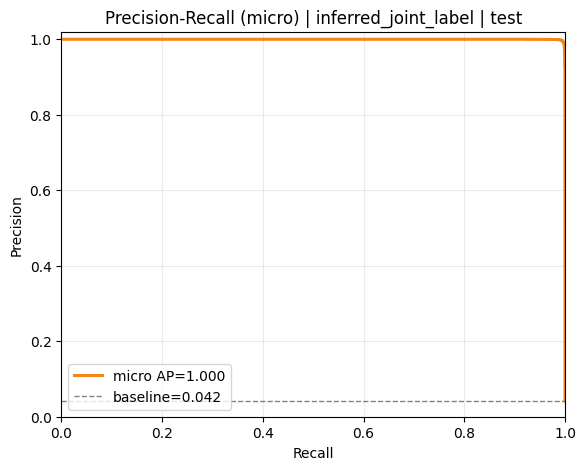

,target,split,artifact,path
0,inferred_joint_label,val,roc_micro,/Users/cmokashi/Documents/GitHub/find_BIDS/out...
1,inferred_joint_label,val,pr_micro,/Users/cmokashi/Documents/GitHub/find_BIDS/out...
2,inferred_joint_label,test,confusion_matrix,/Users/cmokashi/Documents/GitHub/find_BIDS/out...
3,inferred_joint_label,test,roc_micro,/Users/cmokashi/Documents/GitHub/find_BIDS/out...
4,inferred_joint_label,test,pr_micro,/Users/cmokashi/Documents/GitHub/find_BIDS/out...


Saved artifact index: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/plots/finalized_model/final_model_artifacts.csv


In [22]:
detailed_report_tables: dict[str, dict[str, pd.DataFrame]] = {}
detailed_artifacts: list[dict[str, str]] = []

for target in FINAL_TARGETS:
    class_labels = final_models[target]["class_labels"]
    detailed_report_tables[target] = {}

    for split_name in ["val", "test"]:
        pred_block = final_models[target]["predictions"][split_name]
        y_true = pred_block["y_true"].dropna().astype("string")
        y_true = y_true[y_true.isin(class_labels)]
        y_pred = pred_block["y_pred"].loc[y_true.index].astype("string")
        y_proba = pred_block["y_proba"]
        if y_proba is not None:
            y_proba = y_proba.loc[y_true.index].reindex(columns=class_labels, fill_value=0.0)

        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "label"})
        report_df.to_csv(FINAL_METRIC_DIR / f"classification_report_{_safe_plot_slug(target)}_{split_name}.csv", index=False)
        detailed_report_tables[target][split_name] = report_df

        if split_name == "test":
            display(report_df.sort_values("f1-score", ascending=True).head(20))

            top_classes = y_true.value_counts().head(15).index.astype("string").tolist()
            cm = confusion_matrix(y_true, y_pred, labels=top_classes)
            fig, ax = plt.subplots(figsize=(9, 7))
            sns.heatmap(cm, cmap="Blues", ax=ax, xticklabels=top_classes, yticklabels=top_classes)
            ax.set_title(f"Confusion Matrix (Top 15) | {target} | {FINAL_MODEL_NAME} [{split_name}]")
            ax.set_xlabel("Predicted")
            ax.set_ylabel("True")
            cm_path = FINAL_CM_DIR / f"confusion_top15_{_safe_plot_slug(target)}_{split_name}.png"
            fig.savefig(cm_path, dpi=170, bbox_inches="tight")
            plt.show()
            plt.close(fig)
            detailed_artifacts.append({"target": target, "split": split_name, "artifact": "confusion_matrix", "path": str(cm_path)})

        if y_proba is None or len(class_labels) < 2:
            continue

        y_bin = label_binarize(y_true, classes=class_labels)
        valid_class_names = []
        for i, class_name in enumerate(class_labels):
            col = y_bin[:, i]
            if col.sum() > 0 and col.sum() < len(col):
                valid_class_names.append(class_name)

        if not valid_class_names:
            continue

        valid_indices = [class_labels.index(c) for c in valid_class_names]
        y_bin_valid = y_bin[:, valid_indices]
        y_score_valid = y_proba.iloc[:, valid_indices].to_numpy()

        micro_fpr, micro_tpr, _ = roc_curve(y_bin_valid.ravel(), y_score_valid.ravel())
        micro_auc = auc(micro_fpr, micro_tpr)
        fig, ax = plt.subplots(figsize=(6.5, 5.0))
        ax.plot(micro_fpr, micro_tpr, color="#4C78A8", linewidth=2.2, label=f"micro AUC={micro_auc:.3f}")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.0)
        ax.set_title(f"ROC (micro) | {target} | {split_name}")
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.grid(alpha=0.25)
        ax.legend(loc="lower right")
        roc_path = FINAL_ROC_DIR / f"roc_micro_{_safe_plot_slug(target)}_{split_name}.png"
        fig.savefig(roc_path, dpi=170, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        detailed_artifacts.append({"target": target, "split": split_name, "artifact": "roc_micro", "path": str(roc_path)})

        micro_precision, micro_recall, _ = precision_recall_curve(y_bin_valid.ravel(), y_score_valid.ravel())
        micro_ap = average_precision_score(y_bin_valid, y_score_valid, average="micro")
        baseline = float(y_bin_valid.mean())
        fig, ax = plt.subplots(figsize=(6.5, 5.0))
        ax.plot(micro_recall, micro_precision, color="#F58518", linewidth=2.2, label=f"micro AP={micro_ap:.3f}")
        ax.hlines(y=baseline, xmin=0.0, xmax=1.0, linestyle="--", color="gray", linewidth=1.0, label=f"baseline={baseline:.3f}")
        ax.set_title(f"Precision-Recall (micro) | {target} | {split_name}")
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(0.0, 1.02)
        ax.grid(alpha=0.25)
        ax.legend(loc="lower left")
        pr_path = FINAL_PR_DIR / f"pr_micro_{_safe_plot_slug(target)}_{split_name}.png"
        fig.savefig(pr_path, dpi=170, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        detailed_artifacts.append({"target": target, "split": split_name, "artifact": "pr_micro", "path": str(pr_path)})

artifacts_df = pd.DataFrame(detailed_artifacts)
artifacts_csv = FINAL_OUTPUT_DIR / "final_model_artifacts.csv"
artifacts_df.to_csv(artifacts_csv, index=False)

display(artifacts_df)
print(f"Saved artifact index: {artifacts_csv}")

In [23]:
REVIEW_OUTPUT_DIR = PROJECT_DIR / "outputs" / "review"
REVIEW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

keys = ["dataset", "subject_id", "session_id", "series_id"]
unknown_mask = (
    heuristic_scores_df["inferred_datatype"].astype("string").fillna("").str.contains("unknown", case=False)
    | heuristic_scores_df["inferred_suffix"].astype("string").fillna("").str.contains("unknown", case=False)
)
unknown_labels_df = heuristic_scores_df.loc[
    unknown_mask,
    keys + ["inferred_datatype", "inferred_suffix", "min_confidence"],
].copy()
unknown_labels_df = unknown_labels_df.drop_duplicates(subset=keys)

unknown_feature_rows = series_features_df.merge(
    unknown_labels_df[keys],
    on=keys,
    how="inner",
).drop_duplicates(subset=keys)

prepared_unknown = prepare_features_for_modeling(
    unknown_feature_rows,
    drop_raw_text=True,
    sparse_threshold=0.95,
    preserve_engineered_features=True,
)

X_unknown = _to_numeric_ml_matrix(prepared_unknown).reindex(columns=X_train_final.columns, fill_value=0.0)
if len(X_unknown) == 0:
    raise ValueError("No unknown-label rows available for inference after feature preparation.")

review_extra_cols = [c for c in ["series_description"] if c in unknown_feature_rows.columns]
unknown_review = unknown_labels_df.merge(
    unknown_feature_rows[keys + review_extra_cols],
    on=keys,
    how="inner",
)
unknown_review = unknown_review.reset_index(drop=True)
X_unknown = X_unknown.reset_index(drop=True)

target = "inferred_joint_label"
class_labels = final_models[target]["class_labels"]
model = final_models[target]["model"]
fit_info = final_models[target]["fit_info"]

pred_unknown, proba_unknown = _predict_model(model, fit_info, X_unknown, class_labels)
unknown_review["pred_inferred_joint_label"] = pred_unknown.values

if proba_unknown is not None:
    proba_aligned = proba_unknown.reindex(columns=class_labels, fill_value=0.0)
    unknown_review["pred_inferred_joint_label_confidence"] = proba_aligned.max(axis=1).to_numpy()
else:
    unknown_review["pred_inferred_joint_label_confidence"] = np.nan

unknown_preview_cols = keys + review_extra_cols + [
    "inferred_datatype",
    "inferred_suffix",
    "pred_inferred_joint_label",
    "pred_inferred_joint_label_confidence",
]

unknown_review_path = REVIEW_OUTPUT_DIR / "unknown_joint_label_inference_review.csv"
unknown_review.to_csv(unknown_review_path, index=False)
display(unknown_review[unknown_preview_cols].head(50))
print(f"Rows for manual review: {len(unknown_review)}")
print(f"Saved unknown-label inference review: {unknown_review_path}")

,dataset,subject_id,session_id,series_id,series_description,inferred_datatype,inferred_suffix,pred_inferred_joint_label,pred_inferred_joint_label_confidence
0,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912195436662...,Ax T1,anat,unknown,anat::T1w,0.858677
1,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912370620357...,Ax DWI_TRACEW,dwi,unknown,anat::T1w,0.819296
2,proactive,1022-1937,1022-1937-2284-6740,1.3.12.2.1107.5.2.18.52107.2022112912011717349...,Ax DTI_TRACEW,dwi,unknown,dwi::dwiParamMap,0.902547
3,proactive,1022-1937,1022-1937-2343-3438,1.2.840.113619.2.80.2755165863.16402.169453857...,Trace:Sep 12 2023 12-09-32 CDT,dwi,unknown,anat::T1w,0.842397
4,proactive,1022-1937,1022-1937-2343-3438,1.2.840.113619.2.80.2755165863.16402.169453857...,AvDC:Sep 12 2023 12-09-33 CDT,dwi,unknown,dwi::dwiOtherDerived,0.544464
5,proactive,1022-1937,1022-1937-2343-3438,1.2.840.113619.2.408.5.1599194.3702439.16795.1...,Universal:352:AvDC:Sep 12 2023 12-09-33 CDT,dwi,unknown,anat::FLAIR,0.624915
6,proactive,1022-1937,1022-1937-2392-9110,1.2.840.113619.2.80.2755165863.30343.168937119...,Trace:Jul 14 2023 16-46-39 CDT,dwi,unknown,dwi::dwiParamMap,0.838811
7,proactive,1022-1937,1022-1937-2392-9110,1.2.840.113619.2.80.2755165863.30343.168937120...,AvDC:Jul 14 2023 16-46-41 CDT,dwi,unknown,anat::T1w,0.844198
8,proactive,1022-1937,1022-1937-2392-9110,1.2.840.113619.2.408.5.1599194.3702439.32707.1...,Universal:552:AvDC:Jul 14 2023 16-46-41 CDT,dwi,unknown,anat::FLAIR,0.476788
9,proactive,1022-1937,1022-1937-2392-9116,1.2.840.113619.2.25.4.42427253.1689373976.512,COL:MRA Head,dwi,unknown,perf::perfCbfLikeMap,0.657612


Rows for manual review: 12527
Saved unknown-label inference review: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/review/unknown_joint_label_inference_review.csv


In [24]:
REPORT_OUTPUT_DIR = PROJECT_DIR / "outputs" / "reports"
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

report_lines: list[str] = []
report_lines.append("# Final Model Experiment Report")
report_lines.append("")
report_lines.append(f"Generated: {pd.Timestamp.now().isoformat()}")
report_lines.append("")
report_lines.append("## Finalized Configuration")
report_lines.append(f"- Model family: {FINAL_MODEL_NAME}")
report_lines.append("- Training regime: weighted_min_confidence")
report_lines.append("- Target: inferred_joint_label")
report_lines.append(f"- Train rows: {len(X_train_final)}, Val rows: {len(X_val_final)}, Test rows: {len(X_test_final)}")
report_lines.append(f"- Numeric feature count: {X_train_final.shape[1]}")
report_lines.append("")

report_lines.append("## Benchmark Context (Joint Label)")
if "best_by_target" in globals():
    joint_rows = best_by_target[best_by_target["target"] == "inferred_joint_label"].sort_values(
        ["test_f1_macro", "test_auc_macro_ovr"],
        ascending=[False, False],
    )
    for _, row in joint_rows.iterrows():
        report_lines.append(
            "- "
            f"target={row['target']}, benchmark={row['benchmark']}, model={row['model']}, "
            f"test_f1_macro={row['test_f1_macro']:.4f}, test_auc_macro_ovr={row['test_auc_macro_ovr']:.4f}, "
            f"test_balanced_accuracy={row['test_balanced_accuracy']:.4f}"
        )
report_lines.append("")

report_lines.append("## Final Model Metrics (Joint Label)")
for _, row in final_eval_df.sort_values(["target", "split"]).iterrows():
    report_lines.append(
        "- "
        f"target={row['target']}, split={row['split']}, accuracy={row['accuracy']:.4f}, "
        f"balanced_accuracy={row['balanced_accuracy']:.4f}, f1_macro={row['f1_macro']:.4f}, "
        f"auc_macro_ovr={row['auc_macro_ovr']:.4f}"
    )
report_lines.append("")

report_lines.append("## Unknown-Label Inference Review")
report_lines.append(f"- Unknown rows scored: {len(unknown_review)}")
report_lines.append(f"- Review file: {unknown_review_path}")
report_lines.append("")

report_lines.append("## Saved Artifacts")
report_lines.append(f"- Metric table CSV: {final_eval_csv}")
report_lines.append(f"- Artifact index CSV: {artifacts_csv}")
if len(artifacts_df):
    for _, row in artifacts_df.iterrows():
        report_lines.append(f"- [{row['target']}] [{row['split']}] {row['artifact']}: {row['path']}")
report_lines.append("")

report_lines.append("## Finalization Notes")
report_lines.append("- Final model choice fixed to xgboost_depth6 to simplify deployment and maintenance.")
report_lines.append("- Workflow narrowed to joint-label prediction only, as primary project objective.")
report_lines.append("- Weighted training retained because it improved minority-class behavior in benchmark diagnostics.")
report_lines.append("- PR diagnostics are emphasized for imbalance-sensitive evaluation; ROC retained as a secondary view.")

final_report_path = REPORT_OUTPUT_DIR / "final_joint_label_experiment_report.md"
final_report_path.write_text("\n".join(report_lines), encoding="utf-8")

print(f"Saved report: {final_report_path}")
print("\n".join(report_lines[:35]))

Saved report: /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/reports/final_joint_label_experiment_report.md
# Final Model Experiment Report

Generated: 2026-04-13T12:18:29.089021

## Finalized Configuration
- Model family: xgboost_depth6
- Training regime: weighted_min_confidence
- Target: inferred_joint_label
- Train rows: 45474, Val rows: 9773, Test rows: 11622
- Numeric feature count: 519

## Benchmark Context (Joint Label)
- target=inferred_joint_label, benchmark=unweighted, model=extra_trees_depth35_leaf2, test_f1_macro=0.8343, test_auc_macro_ovr=0.9998, test_balanced_accuracy=0.8037
- target=inferred_joint_label, benchmark=weighted_min_confidence, model=extra_trees_depth25, test_f1_macro=0.8265, test_auc_macro_ovr=0.9998, test_balanced_accuracy=0.8182

## Final Model Metrics (Joint Label)
- target=inferred_joint_label, split=test, accuracy=0.9951, balanced_accuracy=0.7983, f1_macro=0.7842, auc_macro_ovr=0.9993
- target=inferred_joint_label, split=val, accuracy=0.9958, balance

## Analysis Data Export

Exports data that `ml_analysis.ipynb` loads for presentation-quality analysis. All artifacts are written to `outputs/analysis_data/`.

Saved files:
- `heuristic_scores_with_splits.csv` — full heuristic scores dataframe with split assignment and ML predictions joined in
- `split_summary.csv` — row counts per split

In [25]:
ANALYSIS_DATA_DIR = PROJECT_DIR / "outputs" / "analysis_data"
ANALYSIS_DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- build split membership index ---
split_rows = []
for split_name, split in weighted_sets.items():
    for idx in split.X.index:
        split_rows.append({"_row_idx": idx, "ml_split": split_name})
split_membership = pd.DataFrame(split_rows).set_index("_row_idx")

# --- extract val + test ML predictions with top-class confidence ---
_target = "inferred_joint_label"
pred_rows = []
for split_name in ("val", "test"):
    preds = final_models[_target]["predictions"][split_name]
    y_pred_s = preds["y_pred"]
    y_proba_df = preds["y_proba"]
    for idx in y_pred_s.index:
        pred_label = y_pred_s.loc[idx]
        confidence = float(y_proba_df.loc[idx, pred_label]) if (y_proba_df is not None and pred_label in y_proba_df.columns) else float("nan")
        pred_rows.append({
            "_row_idx": idx,
            "ml_pred_joint_label": pred_label,
            "ml_pred_confidence": confidence,
        })
ml_predictions = pd.DataFrame(pred_rows).set_index("_row_idx")

# --- join everything onto heuristic_scores_df ---
analysis_df = heuristic_scores_df.copy()
analysis_df = analysis_df.join(split_membership, how="left")
analysis_df = analysis_df.join(ml_predictions, how="left")

# rows with unknown label that were excluded from train/val/test are "excluded" in ml_split
analysis_df["ml_split"] = analysis_df["ml_split"].fillna("excluded")

out_path = ANALYSIS_DATA_DIR / "heuristic_scores_with_splits.csv"
analysis_df.to_csv(out_path, index=False)

# --- split summary ---
split_summary = (
    analysis_df.groupby("ml_split")
    .size()
    .rename("rows")
    .reset_index()
    .rename(columns={"ml_split": "split"})
)
split_summary.to_csv(ANALYSIS_DATA_DIR / "split_summary.csv", index=False)

print(f"Saved {len(analysis_df)} rows → {out_path}")
display(split_summary)
display(analysis_df[["dataset","subject_id","series_id","inferred_datatype","inferred_suffix","min_confidence","label","ml_split","ml_pred_joint_label","ml_pred_confidence"]].head(10))


Saved 144358 rows → /Users/cmokashi/Documents/GitHub/find_BIDS/outputs/analysis_data/heuristic_scores_with_splits.csv


,split,rows
0,all,77489
1,test,11622
2,train,45474
3,val,9773


,dataset,subject_id,series_id,inferred_datatype,inferred_suffix,min_confidence,label,ml_split,ml_pred_joint_label,ml_pred_confidence
0,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112911590867089...,localizer,localizer,0.582783,localizer_localizer,all,localizer::localizer,0.999983
0,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112911590867089...,localizer,localizer,0.582783,localizer_localizer,val,localizer::localizer,0.999983
1,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912032862322...,anat,T2w,0.823201,anat_T2w,train,NaN,NaN
1,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912032862322...,anat,T2w,0.823201,anat_T2w,all,NaN,NaN
2,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912070827969...,anat,FLAIR,0.525680,anat_FLAIR,all,anat::T2w,0.999963
2,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912070827969...,anat,FLAIR,0.525680,anat_FLAIR,val,anat::T2w,0.999963
3,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912121751467...,anat,T2w,0.525680,anat_T2w,train,NaN,NaN
3,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912121751467...,anat,T2w,0.525680,anat_T2w,all,NaN,NaN
4,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912150182192...,anat,T2starw,0.717083,anat_T2starw,all,NaN,NaN
5,proactive,1022-1937,1.3.12.2.1107.5.2.18.52107.2022112912195436662...,anat,unknown,0.000000,anat_unknown,train,NaN,NaN
